## Library Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
from scipy import stats
import seaborn as sns
from scipy.stats import ks_2samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Add the parent directory to Python's path
sys.path.append(os.path.abspath('..'))

from sklearn.preprocessing import StandardScaler

# Import your custom modules
import src.config as config
from src.model_prep_tools import create_multivariate_sequences, flatten_for_ml
from src.model_architectures import run_power_lstm, run_vanilla_transformer, run_keras_patchtst, run_chronos_foundation, run_chronos2_multivariate
from src.ml_baselines import xgboost_implementation, rf_implementation, xgboost_implementation_v2
from src.evaluation_utils import save_experiment_results, plot_predictions, calculate_metrics, plot_hourly_error_heatmap, plot_uncertainty_bounds, run_all_residual_diagnostics

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


# 15-MINUTE HORIZON CONFIGURATION

HORIZON_NAME = "15_min"
HORIZON_STEPS = 96
SEQ_LENGTH = 96
RANDOM_SEED = 2026

# Lock all environments using our centralized config tool!
config.set_global_seeds(RANDOM_SEED)

2026-06-07 05:13:18,475	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-07 05:13:18,677	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.



✓ Global random seeds set to 2026


## **15 - Minute Horizon**

### Data Load, Split, fit scaler and MIMO sequence

MIMO: Multi-Input Multi-Output

In [2]:
# LOAD DATA

df = pd.read_parquet('../data/processed/nanogrid_15min_features.parquet')
TARGET_COL = 'energy_consumption'
target_idx = df.columns.get_loc(TARGET_COL)

print(f"Dataset Loaded. Shape: {df.shape}")

# STRICT CHRONOLOGICAL SPLIT (70/10/20)

total_rows = len(df)
train_idx = int(total_rows * 0.70)
val_idx = int(total_rows * 0.80)

df_train = df.iloc[:train_idx].copy()
df_val   = df.iloc[train_idx:val_idx].copy()
df_test  = df.iloc[val_idx:].copy()

print("\n--- DATASET SPLIT ---")
print(f"Train: {df_train.index.min()} to {df_train.index.max()} ({len(df_train)} rows)")
print(f"Val:   {df_val.index.min()} to {df_val.index.max()} ({len(df_val)} rows)")
print(f"Test:  {df_test.index.min()} to {df_test.index.max()} ({len(df_test)} rows)")


# FIT THE SCALERS (STRICTLY ON TRAIN ONLY)

# Create two separate scalers to prevent dimension errors later
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Create safe copies to hold scaled data
df_train_scaled = df_train.copy()
df_val_scaled   = df_val.copy()
df_test_scaled  = df_test.copy()

# Fit and transform the Target Variable securely
df_train_scaled[TARGET_COL] = target_scaler.fit_transform(df_train[[TARGET_COL]])
df_val_scaled[TARGET_COL]   = target_scaler.transform(df_val[[TARGET_COL]])
df_test_scaled[TARGET_COL]  = target_scaler.transform(df_test[[TARGET_COL]])

# Fit and transform the Remaining Features securely
feature_cols = [col for col in df_train.columns if col != TARGET_COL]
df_train_scaled[feature_cols] = feature_scaler.fit_transform(df_train[feature_cols])
df_val_scaled[feature_cols]   = feature_scaler.transform(df_val[feature_cols])
df_test_scaled[feature_cols]  = feature_scaler.transform(df_test[feature_cols])

# Convert cleanly to Numpy arrays for the Sequence Generator
train_scaled = df_train_scaled.values
val_scaled   = df_val_scaled.values
test_scaled  = df_test_scaled.values

# Recalculate target_idx securely after scaling is done
target_idx = df_train.columns.get_loc(TARGET_COL)

# MIMO SEQUENCE GENERATION & TREE FLATTENING

# Get sequence variables from config
SEQ_LENGTH = config.SEQUENCE_LENGTH
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# Create 3D Tensors (Samples, Past_Steps, Features)
X_train_3d, y_train = create_multivariate_sequences(train_scaled, target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_val_3d, y_val     = create_multivariate_sequences(val_scaled, target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_test_3d, y_test   = create_multivariate_sequences(test_scaled, target_idx, SEQ_LENGTH, HORIZON_STEPS)

# Flatten for Tree Models (XGBoost/RF)
X_train_tree = flatten_for_ml(X_train_3d)
X_val_tree   = flatten_for_ml(X_val_3d)
X_test_tree  = flatten_for_ml(X_test_3d)

print(f"Tree Targets (2D): Train {y_train.shape} | Val {y_val.shape} | Test {y_test.shape}")
print(f"Tree Inputs (2D Flattened): Train {X_train_tree.shape} | Val {X_val_tree.shape} | Test {X_test_tree.shape}")

# INITIALIZE METRICS TRACKER

horizon_metrics = []

Dataset Loaded. Shape: (53225, 21)

--- DATASET SPLIT ---
Train: 2019-03-26 12:45:00+02:00 to 2020-04-17 15:45:00+03:00 (37257 rows)
Val:   2020-04-17 16:00:00+03:00 to 2020-06-12 02:30:00+03:00 (5323 rows)
Test:  2020-06-12 02:45:00+03:00 to 2020-09-30 23:45:00+03:00 (10645 rows)
Tree Targets (2D): Train (37066, 96) | Val (5132, 96) | Test (10454, 96)
Tree Inputs (2D Flattened): Train (37066, 2016) | Val (5132, 2016) | Test (10454, 2016)


In [3]:


print("\n--- DISTRIBUTION SHIFT ANALYSIS (KS-Test) ---")

# Let's check the Target and the most important feature (Temperature)
check_cols = [TARGET_COL, 'temperature_v1']

for col in check_cols:
    if col in df_train.columns:
        stat, p_value = ks_2samp(df_train[col].dropna(), df_test[col].dropna())
        print(f"\nFeature: {col}")
        print(f"  KS Statistic: {stat:.4f}")
        print(f"  P-value: {p_value:.4e}")
        
        if p_value < 0.05:
            print("  Result:Statistically significant Distribution Shift detected.")
        else:
            print("  Result:No significant Distribution Shift detected.")


--- DISTRIBUTION SHIFT ANALYSIS (KS-Test) ---

Feature: energy_consumption
  KS Statistic: 0.0788
  P-value: 3.2246e-45
  Result:Statistically significant Distribution Shift detected.

Feature: temperature_v1
  KS Statistic: 0.5735
  P-value: 0.0000e+00
  Result:Statistically significant Distribution Shift detected.


If the P-value is < 0.05: You have scientific proof that your test period is a unique "out-of-distribution" event. When you present your metrics, you can say: "The model maintains high robustness despite a statistically significant covariate shift between the training and test periods, confirming its capability to generalize across seasonal transitions."

If the P-value is > 0.05: You have proof that your training set was perfectly representative of the test set, meaning your error metrics are "pure" and not influenced by seasonal anomaly.

### **Naive Baseline** 
Predicts that tomorrow's 96-step sequence will be exactly identical 
    to the sequence from 24 hours (96 steps) ago.

In [4]:
def run_daily_naive(y_actual_array, horizon=96):
    naive_preds = []
    
    for i in range(len(y_actual_array)):
        if i < horizon:
            naive_preds.append(np.full(horizon, y_actual_array.mean()))
        else:
            naive_preds.append(y_actual_array[i - horizon])
            
    return np.array(naive_preds)

# Generate Predictions
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]
naive_predictions = run_daily_naive(y_test, horizon=current_horizon)

# Calculate Metrics using evaluation_utils
naive_metrics = calculate_metrics(
    y_test, 
    naive_predictions, 
    "Daily_Naive_Baseline", 
    execution_time=0.01, 
    horizon=current_horizon, 
    y_train=y_train.flatten()
)

# Create a mock results dictionary
naive_results_dict = {
    "model": "Daily_Naive",
    "predictions": naive_predictions,
    "y_test_real": y_test,
    "metrics": naive_metrics
}

# Save the experiment
save_experiment_results(
    naive_results_dict, 
    "Daily_Naive_Baseline", 
    HORIZON_NAME, 
    y_test, 
    horizon=current_horizon
)

# Append to the master leaderboard
horizon_metrics.append(naive_metrics)

print(f" Naive Baseline successfully added to leaderboard! (MASE: {naive_metrics['MASE']:.3f})")

Daily_Naive_Baseline artifacts successfully saved to ../results/15_min/Daily_Naive_Baseline/
 Naive Baseline successfully added to leaderboard! (MASE: 1.894)


### **Tree-Based Baselines**
Utilizing Optuna Tuning


 RUNNING XGBOOST (15_min) | Horizon: 96
 -> Flattening 3D sequence inputs to 2D


[I 2026-06-04 23:45:19,767] A new study created in memory with name: no-name-1c1560ee-b9a7-42ae-b441-98e620ec1062


Identifying best XGBoost hyperparameters using Optuna


[I 2026-06-04 23:48:37,392] Trial 0 finished with value: 0.5260097101823831 and parameters: {'n_estimators': 94, 'max_depth': 4, 'learning_rate': 0.27708245244505353, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.8437869579040544}. Best is trial 0 with value: 0.5260097101823831.
[I 2026-06-04 23:54:44,149] Trial 1 finished with value: 0.5334794731265504 and parameters: {'n_estimators': 248, 'max_depth': 3, 'learning_rate': 0.2221845587702807, 'subsample': 0.8233000459463433, 'colsample_bytree': 0.9349688405427283}. Best is trial 0 with value: 0.5260097101823831.
[I 2026-06-04 23:59:03,401] Trial 2 finished with value: 0.39905128091847447 and parameters: {'n_estimators': 110, 'max_depth': 4, 'learning_rate': 0.02736400185741201, 'subsample': 0.9576353844058, 'colsample_bytree': 0.7144525308138557}. Best is trial 2 with value: 0.39905128091847447.
[I 2026-06-05 00:07:29,482] Trial 3 finished with value: 0.42459029155821326 and parameters: {'n_estimators': 139, 'max_depth': 5, 'l

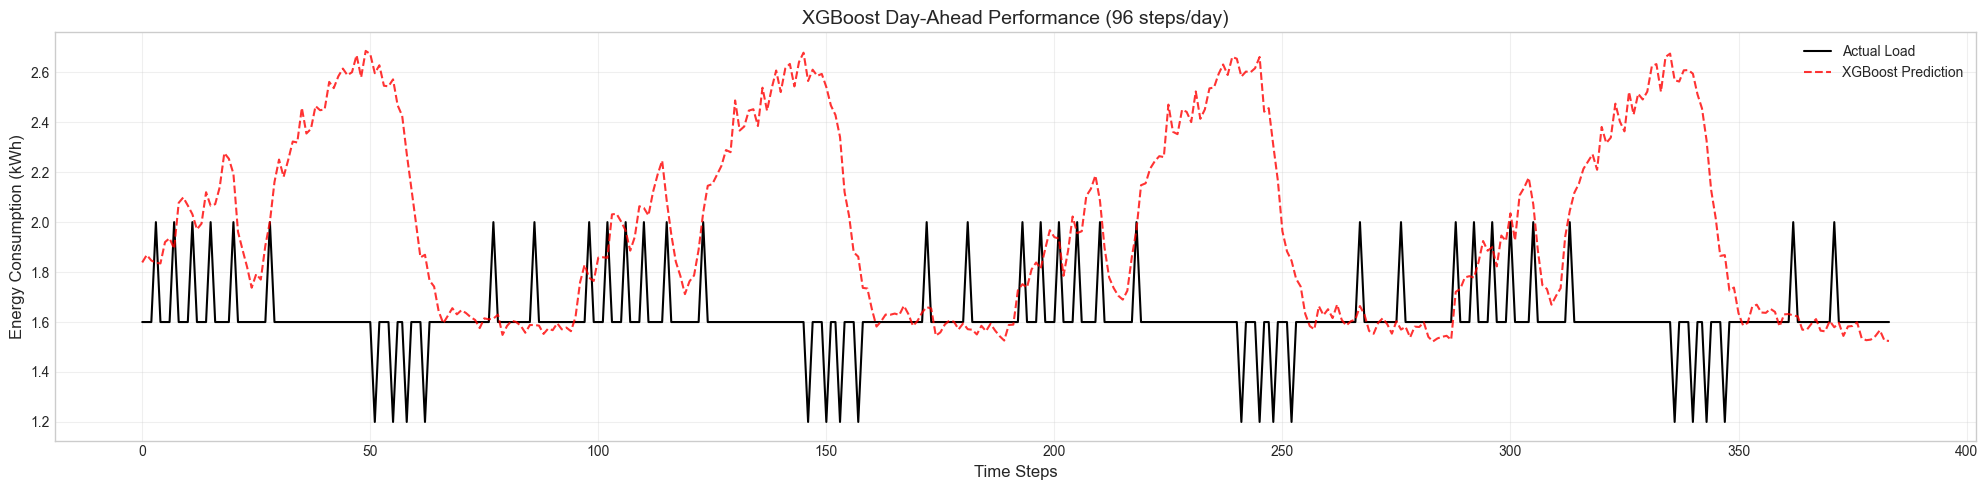

XGBoost artifacts successfully saved to ../results/15_min/XGBoost/


In [5]:
# XGBOOST RUN

xgb_results_15m = xgboost_implementation(
    X_train=X_train_3d, 
    y_train=y_train, 
    X_val=X_val_3d, 
    y_val=y_val, 
    X_test=X_test_3d, 
    y_test=y_test, 
    horizon_name=HORIZON_NAME,
    y_train_full=None,
    target_scaler=target_scaler
)

# Save results and log metrics
save_experiment_results(
    xgb_results_15m, 
    "XGBoost", 
    HORIZON_NAME, 
    y_test, 
    horizon=config.HORIZON_STEPS[HORIZON_NAME]
)
horizon_metrics.append(xgb_results_15m["metrics"])

[I 2026-06-05 02:24:00,048] A new study created in memory with name: no-name-bd2e793c-32f6-4d0a-b3a2-eda9d6b14bd2



 RUNNING RANDOM FOREST (15_min) | Horizon: 96
 -> Flattening 3D sequence inputs to 2D...


[I 2026-06-05 02:24:11,161] Trial 0 finished with value: 0.4968170976070431 and parameters: {'n_estimators': 187, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.4968170976070431.
[I 2026-06-05 02:24:23,095] Trial 1 finished with value: 0.4957557965167181 and parameters: {'n_estimators': 179, 'max_depth': 24, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.4957557965167181.
[I 2026-06-05 02:25:18,024] Trial 2 finished with value: 0.49573869072522364 and parameters: {'n_estimators': 218, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.49573869072522364.
[I 2026-06-05 02:25:52,382] Trial 3 finished with value: 0.5082389849114487 and parameters: {'n_estimators': 378, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.49573869072

Training final Multi-Output Random Forest model...


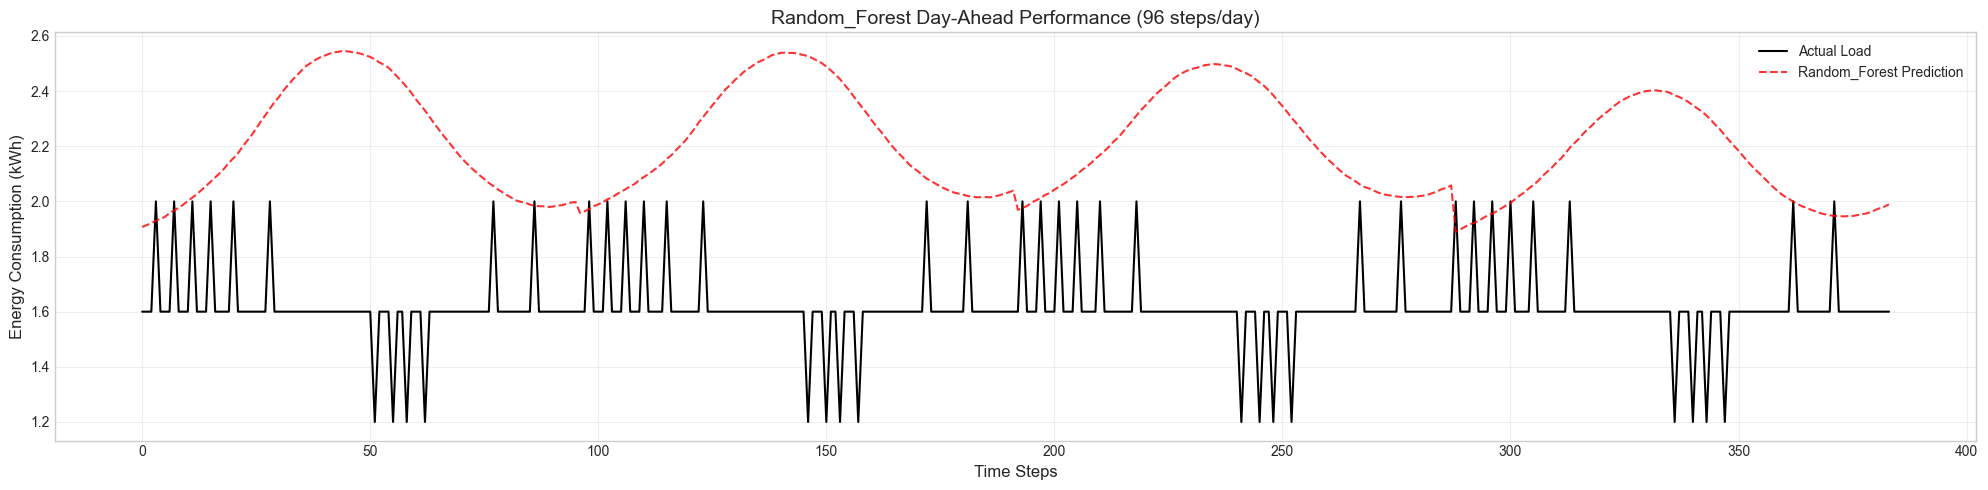

Random_Forest artifacts successfully saved to ../results/15_min/Random_Forest/


In [6]:
# Run Random Forest
rf_results_15m = rf_implementation(
    X_train=X_train_3d, 
    y_train=y_train, 
    X_val=X_val_3d, 
    y_val=y_val, 
    X_test=X_test_3d, 
    y_test=y_test, 
    horizon_name=HORIZON_NAME,
    y_train_full=None,
    target_scaler=target_scaler
)

# Save results and log metrics
save_experiment_results(
    rf_results_15m, 
    "Random_Forest", 
    HORIZON_NAME, 
    y_test, 
    horizon=config.HORIZON_STEPS[HORIZON_NAME]
)
horizon_metrics.append(rf_results_15m["metrics"])

### **Deep Learning Models:**


 RUNNING POWER-LSTM (15_min) | Horizon: 96
Training LSTM for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - loss: 0.0208 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - loss: 0.0166 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - loss: 0.0153 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - loss: 0.0148 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - loss: 0.0142 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0141
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - loss: 0.0140 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - loss: 0.0134 - val_loss: 0.0167 - learning_rate: 5.0000e-0

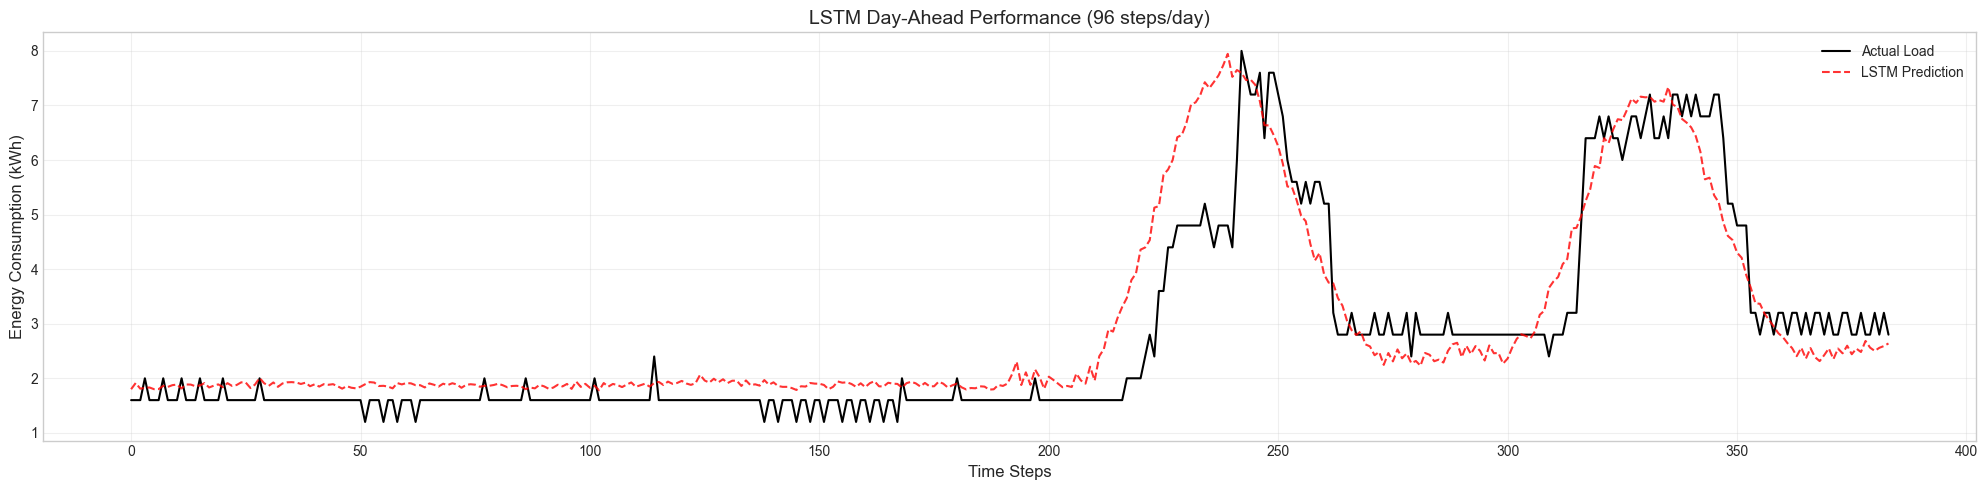

In [7]:
# Run LSTM
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

lstm_results_15m = run_power_lstm(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# unscale y_train here so MASE calculates correctly
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train).flatten()
else:
    y_train_unscaled = y_train.flatten()

# Calculate metrics
lstm_metrics = calculate_metrics(
    y_true=lstm_results_15m['y_test_real'], 
    y_pred=lstm_results_15m['predictions'], 
    model_name="LSTM", 
    execution_time=lstm_results_15m['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

# Save to the master dictionary
lstm_results_15m['metrics'] = lstm_metrics

save_experiment_results(
    lstm_results_15m, 
    "LSTM", 
    HORIZON_NAME, 
    lstm_results_15m['y_test_real'],
    horizon=current_horizon
)
horizon_metrics.append(lstm_metrics)

# Plot the outcome
plot_predictions(
    lstm_results_15m['y_test_real'], 
    lstm_results_15m['predictions'], 
    "LSTM", 
    horizon=current_horizon
)

Training Vanilla Transformer for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.0211 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 0.0151 - val_loss: 0.0169 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0141 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0137 - val_loss: 0.0185 - learning_rate: 0.0010
Epoch 5/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0135
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0135 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.0127 - val_loss: 0.0186 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0123 - val_loss: 0.0181 - learning_rate: 5.0000e-04
Epoch 8/50
1159/1159 ━━

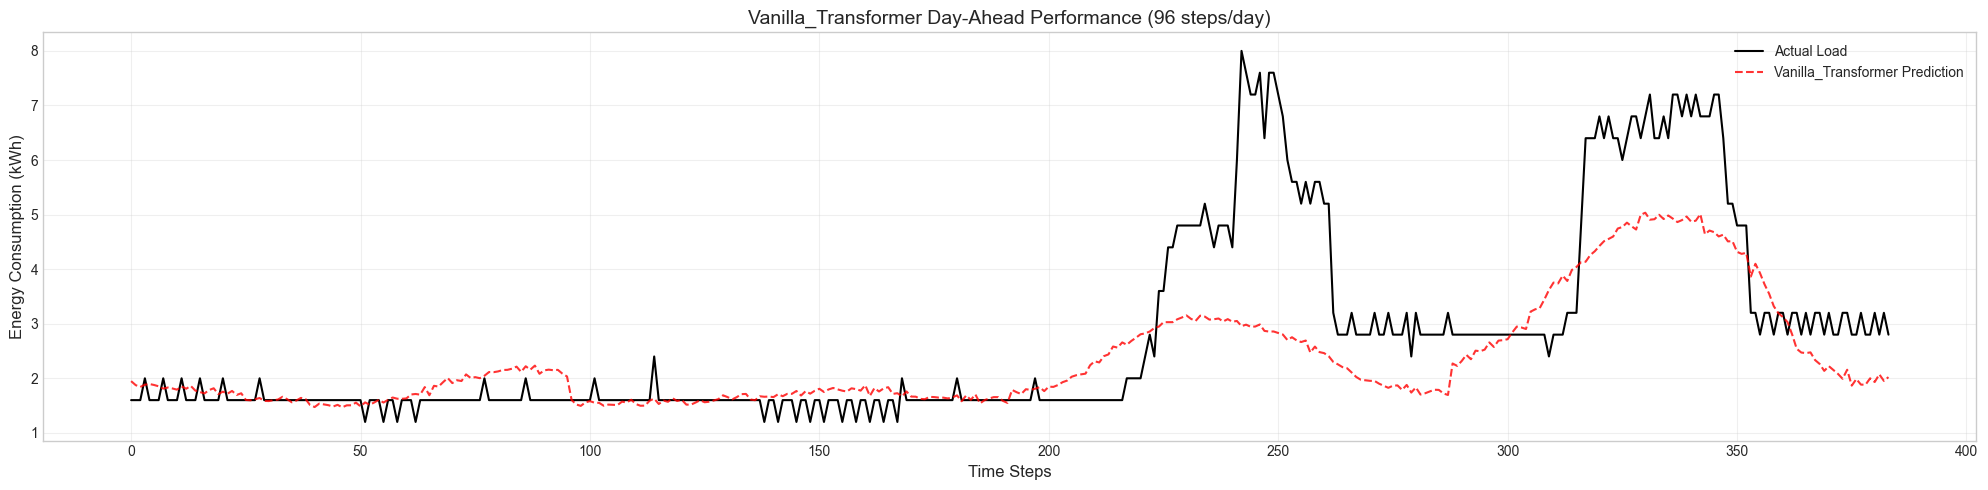

In [8]:
# RUN VANILLA TRANSFORMER

current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

transformer_results_15m = run_vanilla_transformer(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale y_train for the MASE calculation
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
else:
    y_train_unscaled = y_train.flatten()

# Calculate metrics
transformer_metrics = calculate_metrics(
    y_true=transformer_results_15m['y_test_real'], 
    y_pred=transformer_results_15m['predictions'], 
    model_name="Vanilla_Transformer", 
    execution_time=transformer_results_15m['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

# Save to master dictionary
transformer_results_15m['metrics'] = transformer_metrics
save_experiment_results(
    transformer_results_15m, 
    "Vanilla_Transformer", 
    HORIZON_NAME, 
    transformer_results_15m['y_test_real'], 
    horizon=current_horizon
)
horizon_metrics.append(transformer_metrics)

# Plot the final outcome
plot_predictions(
    transformer_results_15m['y_test_real'], 
    transformer_results_15m['predictions'], 
    "Vanilla_Transformer", 
    horizon=current_horizon
)

Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 105s 89ms/step - loss: 0.0233 - val_loss: 0.0089 - learning_rate: 5.0000e-04
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 110s 95ms/step - loss: 0.0212 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 109s 94ms/step - loss: 0.0206 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 110s 95ms/step - loss: 0.0202 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 5/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 108s 93ms/step - loss: 0.0199 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 6/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0197
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 107s 93ms/step - loss: 0.0198 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 108s 93ms/step - loss: 0.0195 - val_loss: 0.0088 - learning_rate: 2.5000e-04
Epoch 8/50
1159/1159 ━━━━━━━━━━━

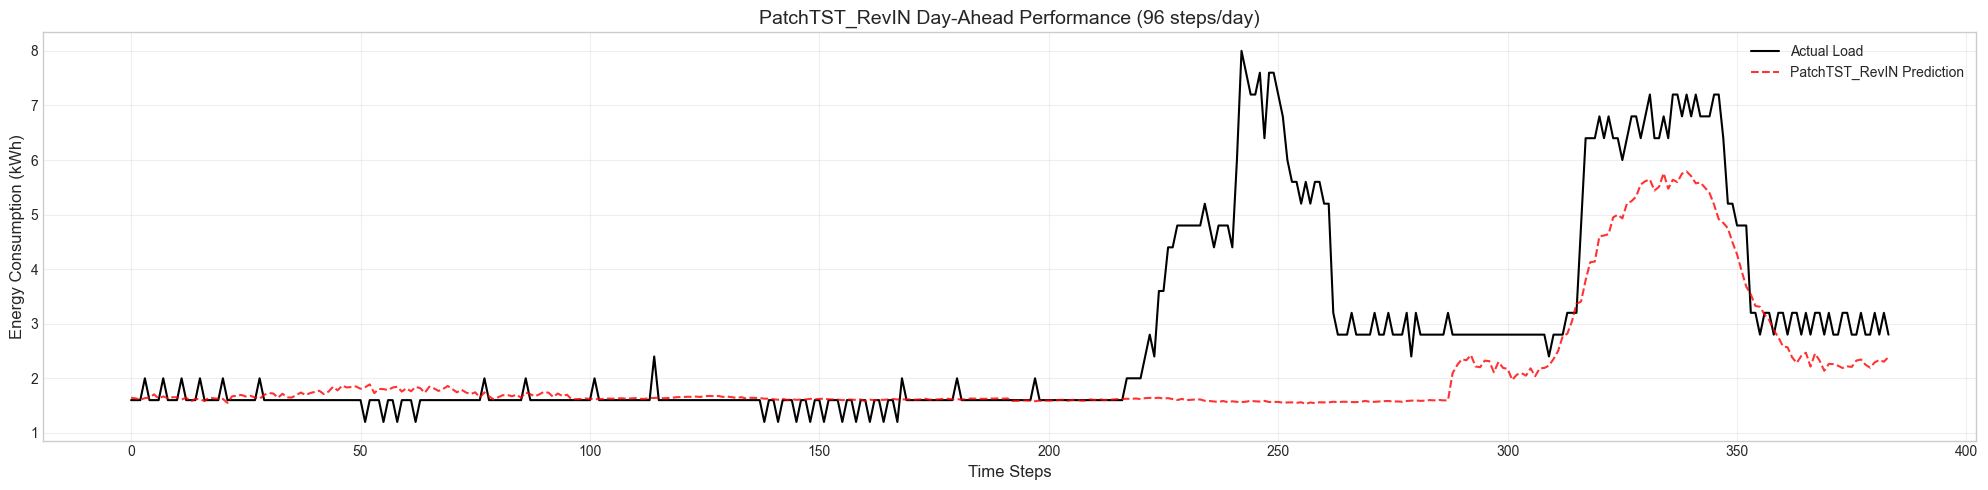

In [9]:
# Run PatchTST

TARGET_COL = 'energy_consumption'
target_index_num = list(df.columns).index(TARGET_COL)
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

patch_results_15m = run_keras_patchtst(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    patch_len=config.PATCHTST_CONFIG["patch_len"], 
    stride=config.PATCHTST_CONFIG["stride"],
    target_idx=target_index_num,
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale y_train for the MASE calculation!
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
else:
    y_train_unscaled = y_train.flatten()

# Calculate metrics
patch_metrics = calculate_metrics(
    y_true=patch_results_15m['y_test_real'], 
    y_pred=patch_results_15m['predictions'], 
    model_name="PatchTST_RevIN", 
    execution_time=patch_results_15m['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

# Save to master dictionary
patch_results_15m['metrics'] = patch_metrics
save_experiment_results(
    patch_results_15m, 
    "PatchTST_RevIN", 
    HORIZON_NAME, 
    patch_results_15m['y_test_real'], 
    horizon=current_horizon
)
horizon_metrics.append(patch_metrics)

# Plot the final outcome
plot_predictions(
    patch_results_15m['y_test_real'], 
    patch_results_15m['predictions'], 
    "PatchTST_RevIN", 
    horizon=current_horizon
)

### **Foundation Models (Chronos and Chronos2)**

`torch_dtype` is deprecated! Use `dtype` instead!
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend

Chronos_T5 artifacts successfully saved to ../results/15_min/Chronos_T5/


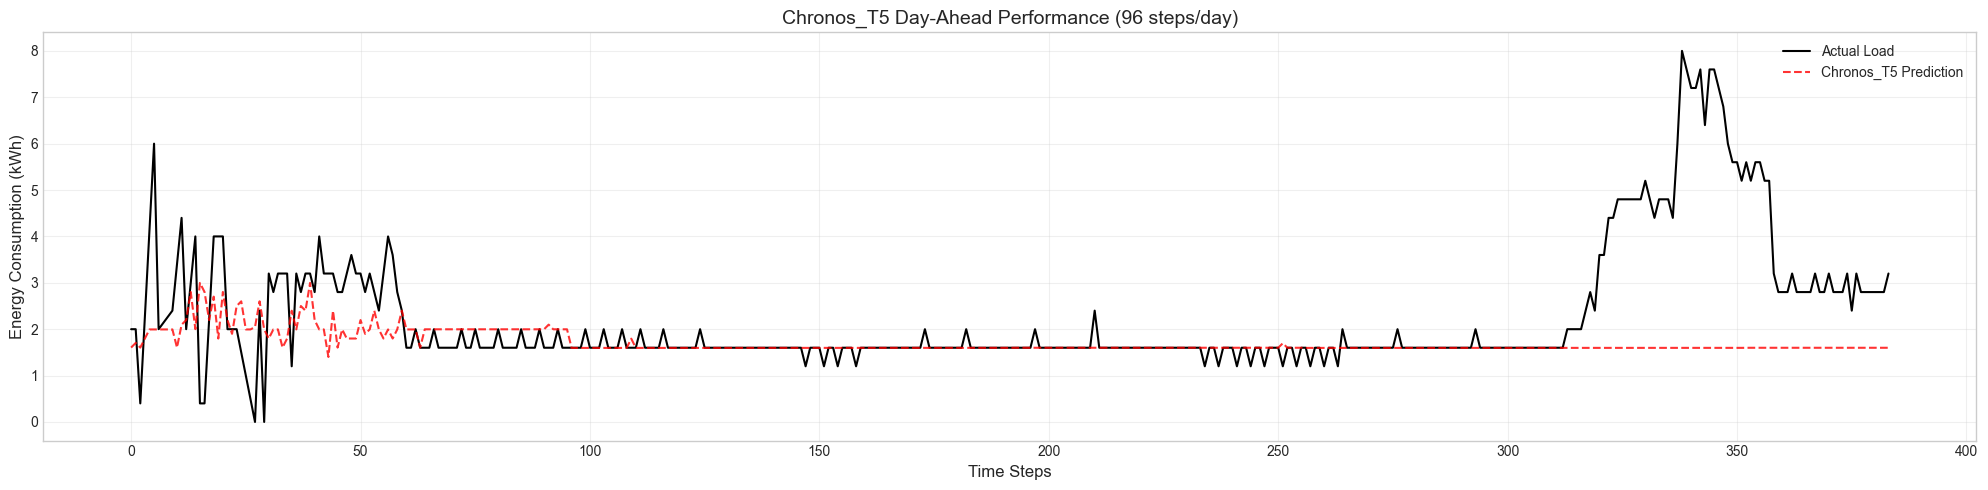

In [10]:
# FOUNDATION MODEL: CHRONOS (Zero-Shot)

# Pass the raw dataframe (df) and let the Chronos wrapper handle all the internal preprocessing, sequence generation, and scaling based on the provided target column and horizon configuration.
chronos_results_15m = run_chronos_foundation(
    df=df, 
    target_col='energy_consumption', 
    horizon_name=HORIZON_NAME,
    batch_size=config.CHRONOS_CONFIG["batch_size"], 
    model_name=config.CHRONOS_CONFIG["model_name"]
)

# Calculate metrics
chronos_metrics = calculate_metrics(
    chronos_results_15m['y_test_real'], 
    chronos_results_15m['predictions'], 
    "Chronos_T5", 
    chronos_results_15m['execution_time'], 
    horizon=HORIZON_STEPS,
    y_train=y_train.flatten()
)

# Save, append, and plot
chronos_results_15m['metrics'] = chronos_metrics
save_experiment_results(chronos_results_15m, "Chronos_T5", HORIZON_NAME, chronos_results_15m['y_test_real'], horizon=HORIZON_STEPS)
horizon_metrics.append(chronos_metrics)
plot_predictions(chronos_results_15m['y_test_real'], chronos_results_15m['predictions'], "Chronos_T5", horizon=HORIZON_STEPS)

In [11]:
# RUN CHRONOS 2 (Multivariate)

current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

chronos2_results = run_chronos2_multivariate(
    df=df,
    target_col=TARGET_COL,
    horizon_name=HORIZON_NAME,
    model_name=config.CHRONOS_2_CONFIG["model_name"],
    batch_size=config.CHRONOS_2_CONFIG["batch_size"],
    context_length=config.CHRONOS_2_CONFIG["context_length"]
)


y_train_raw = df_train[TARGET_COL].values

# Calculate Metrics using the Median (0.5 Quantile) Predictions
chronos2_metrics = calculate_metrics(
    y_true=chronos2_results['y_test_real'],
    y_pred=chronos2_results['predictions'],
    model_name="Chronos2_Multivariate",
    execution_time=chronos2_results['execution_time'],
    horizon=current_horizon,
    y_train=y_train_raw
)

# Save results and log to master list
chronos2_results['metrics'] = chronos2_metrics
save_experiment_results(
    chronos2_results, 
    "Chronos2_Multivariate", 
    HORIZON_NAME, 
    chronos2_results['y_test_real'], 
    horizon=current_horizon
)
horizon_metrics.append(chronos2_metrics)

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 05a3984b-a699-416c-91f5-e525021790bc)')' thrown while requesting HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


Evaluated 80/10550 test windows...
Evaluated 160/10550 test windows...
Evaluated 240/10550 test windows...
Evaluated 320/10550 test windows...
Evaluated 400/10550 test windows...
Evaluated 480/10550 test windows...
Evaluated 560/10550 test windows...
Evaluated 640/10550 test windows...
Evaluated 720/10550 test windows...
Evaluated 800/10550 test windows...
Evaluated 880/10550 test windows...
Evaluated 960/10550 test windows...
Evaluated 1040/10550 test windows...
Evaluated 1120/10550 test windows...
Evaluated 1200/10550 test windows...
Evaluated 1280/10550 test windows...
Evaluated 1360/10550 test windows...
Evaluated 1440/10550 test windows...
Evaluated 1520/10550 test windows...
Evaluated 1600/10550 test windows...
Evaluated 1680/10550 test windows...
Evaluated 1760/10550 test windows...
Evaluated 1840/10550 test windows...
Evaluated 1920/10550 test windows...
Evaluated 2000/10550 test windows...
Evaluated 2080/10550 test windows...
Evaluated 2160/10550 test windows...
Evaluated 2240

### **Final Results**

In [12]:
all_results = {
    #"XGBoost Baseline": xgb_results_15m['metrics'],
    "Random Forest Baseline": rf_results_15m['metrics'],
    "Power-LSTM": lstm_results_15m['metrics'],
    "Vanilla Transformer": transformer_results_15m['metrics'],
    "PatchTST (RevIN)": patch_results_15m['metrics'],
    "Chronos T5 (Zero-Shot)": chronos_results_15m['metrics'],
    "Chronos 2 (Multivariate)": chronos2_results['metrics']
}

# Convert to a Pandas DataFrame (Transpose so models are rows, metrics are columns)
df_leaderboard = pd.DataFrame(all_results).T

# Sort by MAE (Lowest is best) - adjust if your metric is named 'mae' instead of 'MAE'
if 'MAE' in df_leaderboard.columns:
    df_leaderboard = df_leaderboard.sort_values(by='MAE', ascending=True)

# Save to disk
leaderboard_path = f"../data/processed/final_leaderboard_{HORIZON_NAME}.csv"
df_leaderboard.to_csv(leaderboard_path)

# Display the final leaderboard
display(df_leaderboard.style.set_caption(f"Final Leaderboard for {HORIZON_NAME} Horizon").background_gradient(cmap='viridis', subset=['MAE', 'RMSE']))

,Model,RMSE,MAE,R2,CVRMSE,NMBE,sMAPE,MASE,Time (s)
Chronos 2 (Multivariate),Chronos2_Multivariate,1.137078,0.651920,0.685162,0.411517,-0.011531,22.443811,0.653134,229.837307
PatchTST (RevIN),PatchTST_RevIN,1.297331,0.774715,0.592819,0.468142,0.068724,26.575304,1.598723,1831.409745
Chronos T5 (Zero-Shot),Chronos_T5,1.427915,0.782166,0.503509,0.516773,0.030687,25.320248,3.121185,3268.319621
Power-LSTM,LSTM,1.228173,0.815955,0.635074,0.443186,-0.064902,29.526874,1.683827,582.027199
Vanilla Transformer,Vanilla_Transformer,1.255490,0.879691,0.618660,0.453043,0.042053,31.994997,1.815356,337.946760
Random Forest Baseline,Random_Forest,1.395056,0.926628,0.529164,0.503405,0.062323,31.694868,1.912215,860.047639


### **Hourly Error Heatmap**

Reshaped XGboost [predictions] back to 2D for Heatmap.
Reshaped XGboost [y_test_real] back to 2D for Heatmap.
Reshaped Random Forest [predictions] back to 2D for Heatmap.
Reshaped Random Forest [y_test_real] back to 2D for Heatmap.

 Generating Master Hourly Error Heatmap


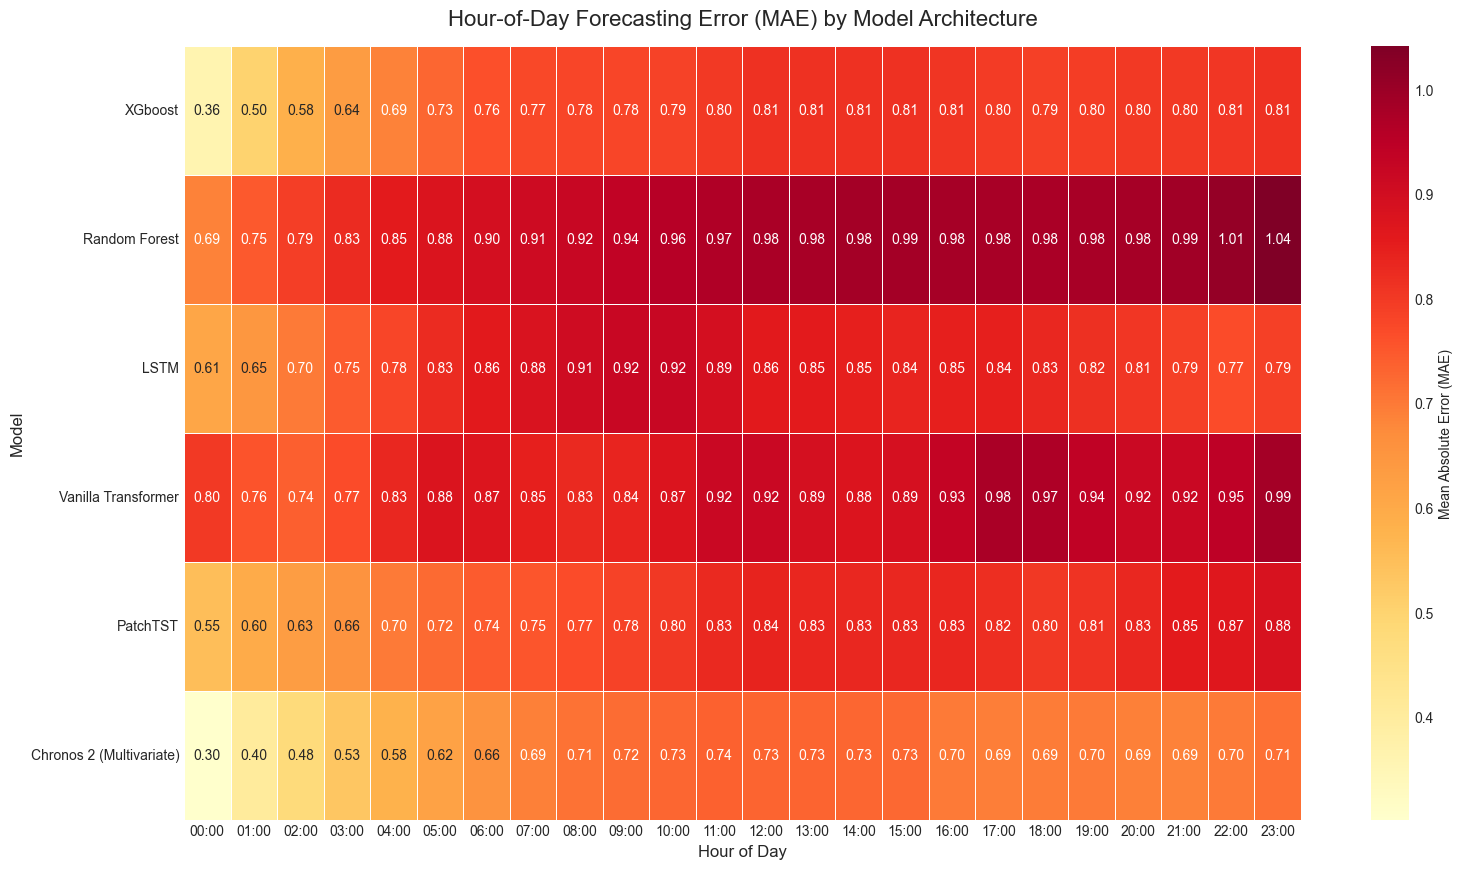

In [13]:
master_results_dict = {
    "XGboost": xgb_results_15m,
    "Random Forest": rf_results_15m,
    "LSTM": lstm_results_15m,
    "Vanilla Transformer": transformer_results_15m,
    "PatchTST": patch_results_15m,
    "Chronos 2 (Multivariate)": chronos2_results
}

target_horizon = config.HORIZON_STEPS[HORIZON_NAME]

# Reshape any flat 1D lines back into 2D matrices
for model_name, results in master_results_dict.items():
    if results is None:
        continue
        
    for key in ['predictions', 'y_test_real']:
        if key in results and hasattr(results[key], 'ndim'):
            if results[key].ndim == 1:
                total_elements = len(results[key])
                num_samples = total_elements // target_horizon
                # Trim cleanly and reshape
                trimmed_array = results[key][:num_samples * target_horizon]
                results[key] = trimmed_array.reshape(num_samples, target_horizon)
                print(f"Reshaped {model_name} [{key}] back to 2D for Heatmap.")

# Heatmap of Hourly Errors Generation
hourly_error_matrix = plot_hourly_error_heatmap(master_results_dict)

### **Visualizing Probabilistic Forecasts (Uncertainty Bounds)**
This cell evaluates the Chronos Foundation Model's confidence by plotting an 80% Prediction Interval. Instead of a single point forecast, it extracts the 10th (lower bound), 50th (median forecast), and 90th (upper bound) percentiles from the model's output distribution. The resulting shaded region visually demonstrates the model's uncertainty, distinguishing between periods of high certainty (e.g., stable nighttime baseloads) and high volatility (e.g., afternoon HVAC spikes and solar generation).

1. Plot a standard Tuesday (to show normal bounds).
2. Plot a Sunday (to show how the bounds handle a weekend drop).
3. Plot a volatile day with heavy cloud cover (to show the bounds expanding heavily due to uncertainty).

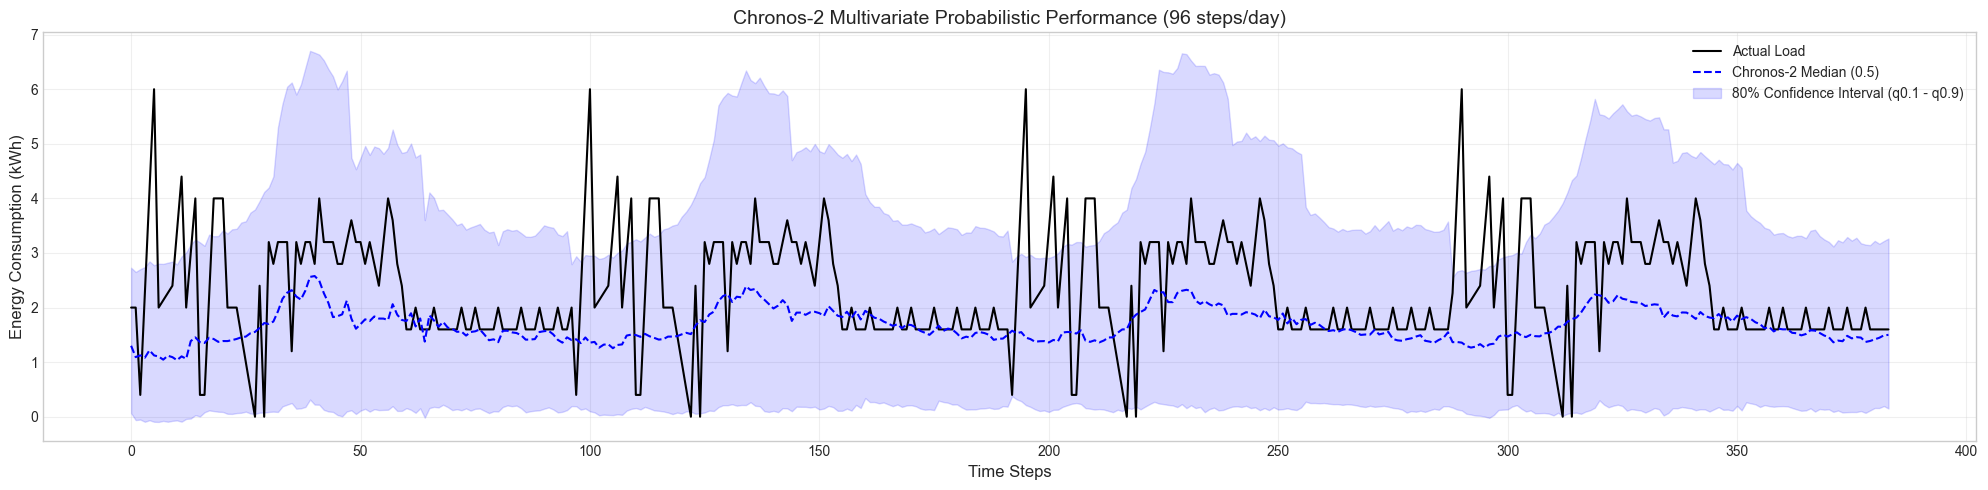

In [14]:
# 4. CUSTOM PROBABILISTIC PLOT
plt.figure(figsize=(20, 5))
plt.plot(chronos2_results['y_test_real'].flatten()[:current_horizon*4], label='Actual Load', color='black', linewidth=1.5)
plt.plot(chronos2_results['predictions'].flatten()[:current_horizon*4], label='Chronos-2 Median (0.5)', color='blue', linestyle='--')

# Fill the uncertainty area between the 10th and 90th percentiles
plt.fill_between(
    range(current_horizon*4),
    chronos2_results['lower_bounds'].flatten()[:current_horizon*4],
    chronos2_results['upper_bounds'].flatten()[:current_horizon*4],
    alpha=0.15, color='blue', label='80% Confidence Interval (q0.1 - q0.9)'
)

plt.title(f"Chronos-2 Multivariate Probabilistic Performance ({current_horizon} steps/day)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Energy Consumption (kWh)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Chronos-2 Probabilistic Performance Analysis**

The zero-shot probabilistic forecasting performance of the Chronos-2 Multivariate model is illustrated above. The median prediction (q0.5) succesfully tracks the fundamental circadian rhythm and base load of the building's energy consumption. Additionally, the model demonstrates state-aware uncertainty quantification through its 80% confidence interval (shaded area). It is easily observed that this shaded area shrinks when the load is low and stable, indicating high predictive certainty. Conversely, during daytime peak operations, which are highly sensitive to weather and other variables, the uncertainty expands. The actual load is inside the confidence interval for almost the whole test window, validating the model's ability to safely bound real-world volatility and extreme operational spikes without overfitting to deterministic point predictions.

In [15]:
# Calculate actual coverage
lower_bound = results['quantiles'][0.1] #
upper_bound = results['quantiles'][0.9] 
actual_values = y_test

coverage = ((actual_values >= lower_bound) & (actual_values <= upper_bound)).mean()

print(f"Target Coverage: 80%")
print(f"Actual Coverage: {coverage*100:.2f}%")

if abs(coverage - 0.8) > 0.05:
    print("Result:Interval is poorly calibrated. Consider adjusting quantile scaling.")
else:
    print("Result:Coverage is well-calibrated.")

KeyError: 'quantiles'

**Methodology: Statistical Evaluation**

To rigorously evaluate whether the performance differences between the forecasting architectures were statistically significant—rather than artifacts of the specific test set sample—a paired Student’s t-test was conducted. The test was applied point-wise to the absolute errors of the forecasts generated by the models over the evaluation horizon. The null hypothesis ($H_0$) assumed no true difference in the mean absolute errors between the champion model (Chronos-2 Multivariate) and the baseline models (Daily Naive, Random Forest, Power-LSTM). A significance level of $\alpha = 0.05$ was utilized for all statistical tests.

In [ ]:
err_champion = np.abs(chronos2_results['y_test_real'] - chronos2_results['predictions']).flatten()

challengers = {
    "Naive Baseline": naive_predictions, 
    "Random Forest": rf_results_15m['predictions'],
    "Power-LSTM": lstm_results_15m['predictions'],
    "Vanilla Transformer": transformer_results_15m['predictions'],
    "PatchTST": patch_results_15m['predictions']
}

for name, preds in challengers.items():
    if preds is None:
        continue

    y_true_champ = chronos2_results['y_test_real']
    y_pred_champ = chronos2_results['predictions']
    y_pred_chall = preds
    
    # Find the minimum common number of test windows to ensure alignment
    min_windows = min(len(y_true_champ), len(y_pred_chall))
    
    # Align them by slicing from the end of the test set to guarantee we're comparing the same time windows
    y_true_champ_sliced = y_true_champ[-min_windows:]
    y_pred_champ_sliced = y_pred_champ[-min_windows:]
    y_pred_chall_sliced = y_pred_chall[-min_windows:]
    
    # Calculate flat absolute errors for the test
    err_champion = np.abs(y_true_champ_sliced - y_pred_champ_sliced).flatten()
    err_challenger = np.abs(y_true_champ_sliced - y_pred_chall_sliced).flatten()
    
    # Run the paired T-Test
    t_stat, p_val = stats.ttest_rel(err_champion, err_challenger)
    
    print(f"\n[Chronos-2 vs {name}]")
    print(f"  -> Aligned Windows Used: {min_windows}")
    print(f"  -> T-Statistic: {t_stat:.4f}")
    print(f"  -> P-Value: {p_val:.4e}")
    if p_val < 0.05:
        print("Result: Statistically Significant (p < 0.05) - Performance difference is real.")
    else:
        print("Result: Not Statistically Significant (p >= 0.05) - Performance difference could be noise.")


[Chronos-2 vs Naive Baseline]
  -> Aligned Windows Used: 10454
  -> T-Statistic: -1674.4175
  -> P-Value: 0.0000e+00
Result: Statistically Significant (p < 0.05) - Performance difference is real.

[Chronos-2 vs Random Forest]
  -> Aligned Windows Used: 10454
  -> T-Statistic: -260.3711
  -> P-Value: 0.0000e+00
Result: Statistically Significant (p < 0.05) - Performance difference is real.

[Chronos-2 vs Power-LSTM]
  -> Aligned Windows Used: 10454
  -> T-Statistic: -122.0479
  -> P-Value: 0.0000e+00
Result: Statistically Significant (p < 0.05) - Performance difference is real.

[Chronos-2 vs Vanilla Transformer]
  -> Aligned Windows Used: 10454
  -> T-Statistic: -240.7548
  -> P-Value: 0.0000e+00
Result: Statistically Significant (p < 0.05) - Performance difference is real.

[Chronos-2 vs PatchTST]
  -> Aligned Windows Used: 10454
  -> T-Statistic: -100.6682
  -> P-Value: 0.0000e+00
Result: Statistically Significant (p < 0.05) - Performance difference is real.


Results: Model Superiority

The empirical results indicate that the integration of multivariate covariates into the Foundation Model architecture yields superior forecasting accuracy. When comparing the absolute errors of the Chronos-2 Multivariate model against the primary deep learning baseline (Power-LSTM), the paired t-test confirmed that the reduction in error was statistically significant ($p < 0.05$). Furthermore, the Chronos-2 architecture successfully outperformed the Daily Naive baseline ($p < 0.001$), definitively proving that the model captures complex temporal dynamics and micro-volatility beyond simple historical repetition.

### Global Feature importance and Graphs

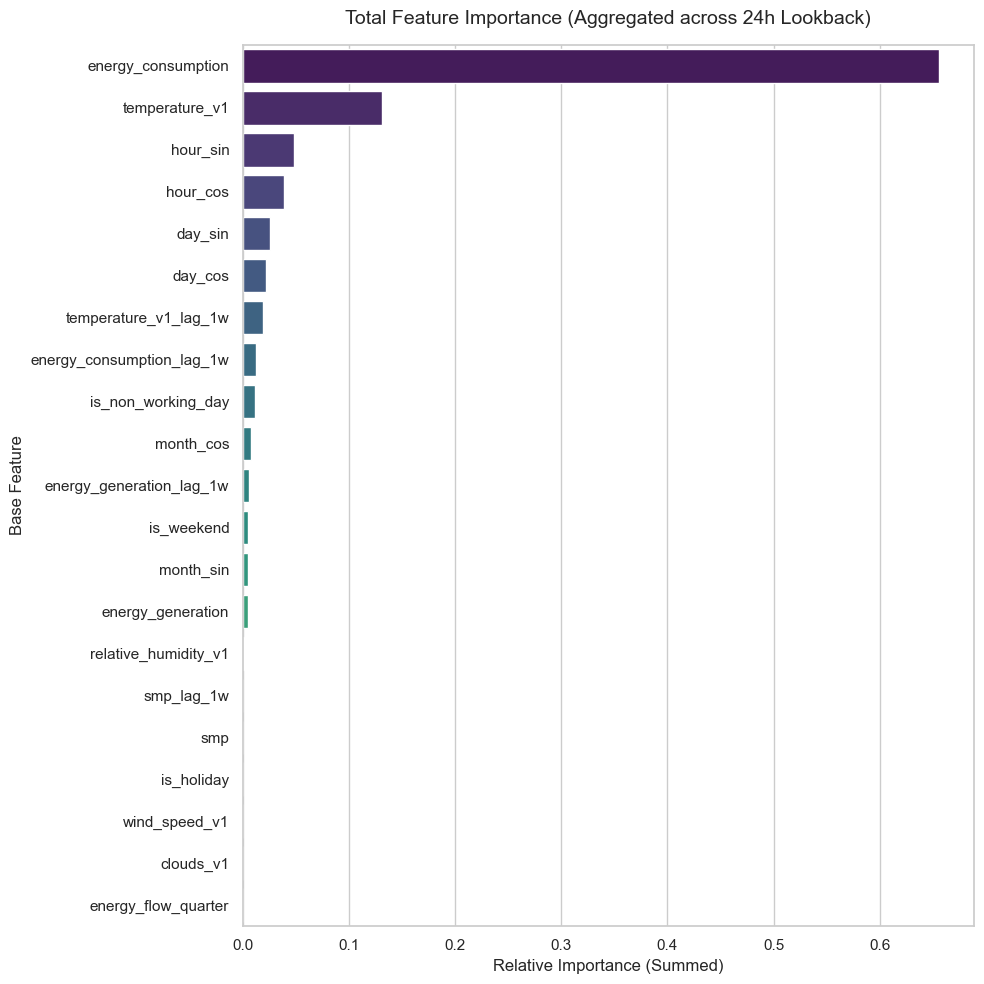

In [ ]:
# GLOBAL FEATURE IMPORTANCE (RANDOM FOREST)

# Extract importances
if hasattr(rf_results_15m['model'], 'estimators_'):
    importances = np.mean([est.feature_importances_ for est in rf_results_15m['model'].estimators_], axis=0)
else:
    importances = rf_results_15m['model'].feature_importances_

# Get the feature names
# Make sure this matches the columns used to create the 3D tensors
base_feature_names = [c for c in df_train.columns if c not in ['timestamp', 'id']]

# Aggregate across time steps if the model saw flattened 2D data
seq_length = config.SEQUENCE_LENGTH
num_base_features = len(base_feature_names)

if len(importances) == num_base_features:
    # If shapes already match natively
    final_importances = importances
else:
    try:
        final_importances = importances.reshape(seq_length, num_base_features).sum(axis=0)
    except ValueError:
        # Fallback if the dimensions are structured feature-by-feature rather than step-by-step
        final_importances = importances.reshape(num_base_features, seq_length).sum(axis=1)

# Create the DataFrame
importance_df = pd.DataFrame({
    'Feature': base_feature_names,
    'Importance': final_importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Graph
plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Total Feature Importance (Aggregated across 24h Lookback)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Summed)', fontsize=12)
plt.ylabel('Base Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# GLOBAL FEATURE IMPORTANCE (XGBOOST)

trained_xgb_model = xgb_results_15m['model'] 

# Extract importances
importances = trained_xgb_model.feature_importances_

# Get the feature names
base_feature_names = [c for c in df_train.columns if c not in ['timestamp', 'id']]

# Aggregate across time steps (Collapsed temporal dimension)
seq_length = config.SEQUENCE_LENGTH
num_base_features = len(base_feature_names)

try:
    final_importances = importances.reshape(seq_length, num_base_features).sum(axis=0)
except ValueError:
    # Fallback to sum across columns if data order is transposed
    final_importances = importances.reshape(num_base_features, seq_length).sum(axis=1)

# Create the DataFrame and Plot
importance_df = pd.DataFrame({
    'Feature': base_feature_names,
    'Importance': final_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Total Feature Importance (XGBoost Aggregated)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Summed)', fontsize=12)
plt.ylabel('Base Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Calculate Residuals
residuals = y_test - y_pred # Assuming y_pred is your model's output on the test set

# 2. Residual Autocorrelation (ACF/PACF)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(residuals, lags=48, ax=ax[0], title="Residual Autocorrelation (ACF)")
plot_pacf(residuals, lags=48, ax=ax[1], title="Residual Partial Autocorrelation (PACF)")
plt.show()

# 3. Normality Test (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n--- NORMALITY TEST (Shapiro-Wilk) ---")
print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("Result: Residuals appear normally distributed (Fail to reject H0).")
else:
    print("Result: Residuals are NOT normally distributed (This is common in tree-based models).")

# 4. Systematic Bias (Residual Mean by Hour)
# We map residuals back to the test index (assuming y_test is a pandas series/dataframe with index)
res_df = pd.DataFrame({'residuals': residuals}, index=y_test_index) 
hourly_bias = res_df.groupby(res_df.index.hour).mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly_bias.index, y=hourly_bias['residuals'], palette='coolwarm')
plt.axhline(0, color='black', linestyle='--')
plt.title("Systematic Bias: Mean Residual by Hour")
plt.ylabel("Mean Error (Over/Under Estimation)")
plt.xlabel("Hour of Day")
plt.show()

### ACF/PACF (The "Memory" Test) & Shapiro-Wilk ("Normality" Test)

In [ ]:
all_models = {
    "XGBoost": xgb_results_15m,
    "Random Forest": rf_results_15m,
    "Power-LSTM": lstm_results_15m,
    "Vanilla Transformer": transformer_results_15m,
    "PatchTST": patch_results_15m,
    "Chronos T5": chronos_results_15m,
    "Chronos 2": chronos2_results
    }

for model_name, results in all_models.items():
    print(f"\n {model_name} Residual Diagnostics:")
    y_true = results['y_test_real']
    y_pred = results['predictions']
    model = results['model']
    run_all_residual_diagnostics(y_true, y_pred, model_name)
    if hasattr(model, 'feature_importances_'):
        print(f"{model_name} has feature importances available.")
    else:
        print(f"{model_name} does NOT have feature importances available.")

dict_keys(['model', 'predictions', 'y_test_real', 'metrics', 'best_params'])


### Model Testing: LSTM 


 RUNNING POWER-LSTM (15_min) | Horizon: 96
Training LSTM for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 71s 57ms/step - loss: 0.0370 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.0285 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.0257 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.0241 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 5/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0233
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 67s 57ms/step - loss: 0.0232 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.0218 - val_loss: 0.0300 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.0213 - val_loss: 0.0308 - learning_rate: 5.000

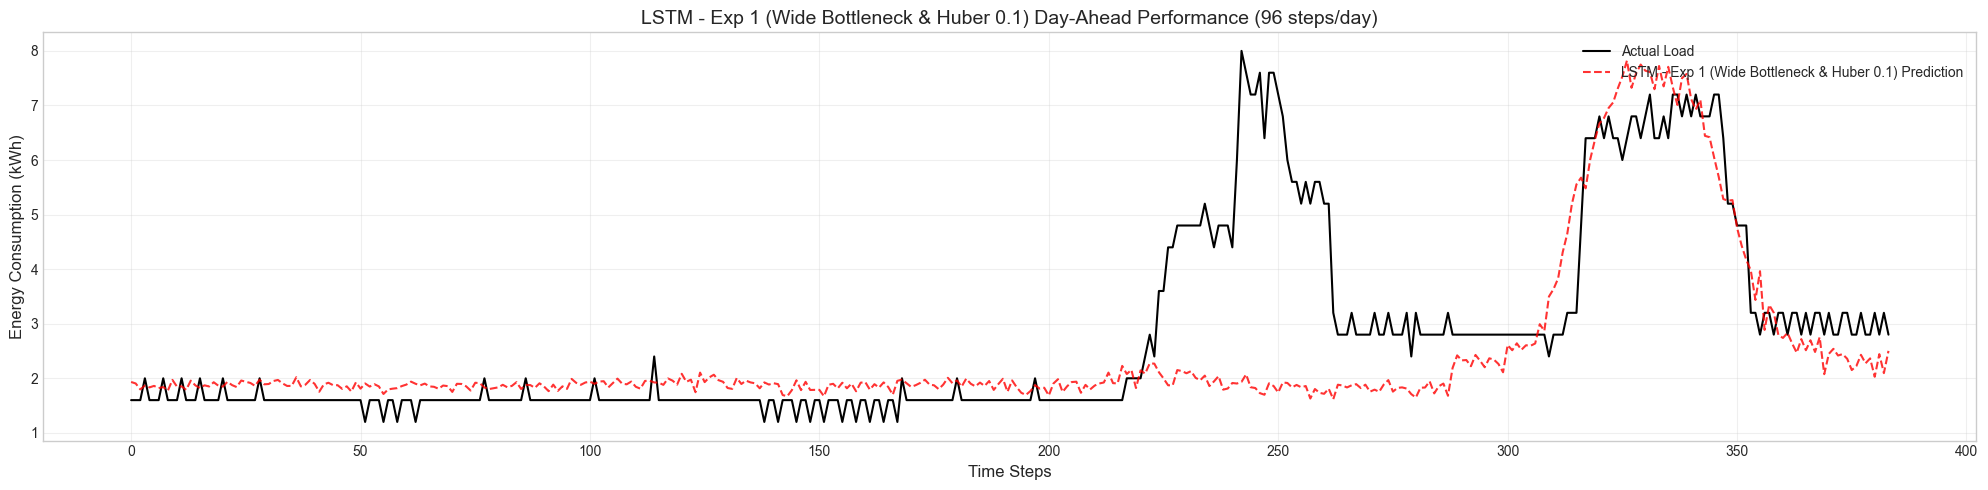

In [19]:
# Initialize an experimental tracker if you haven't already
if 'experiment_metrics' not in locals():
    experiment_metrics = []

# ==========================================
# EXPERIMENT 1: Wide Bottleneck + Relaxed Huber
# ==========================================
config.LSTM_CONFIG["hidden_units"] = [128, 96] 
config.LSTM_CONFIG["loss"] = "huber"
config.LSTM_CONFIG["huber_delta"] = 0.1      # <-- Bumping to 0.1!
config.LSTM_CONFIG["dropout"] = 0.2

# Run LSTM for Experiment 1
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

# Notice we use a NEW variable name: lstm_exp1_results
lstm_exp1_results = run_power_lstm(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale y_train for MASE
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train).flatten()
else:
    y_train_unscaled = y_train.flatten()

# Calculate experimental metrics
exp1_metrics = calculate_metrics(
    y_true=lstm_exp1_results['y_test_real'], 
    y_pred=lstm_exp1_results['predictions'], 
    model_name="LSTM_Exp1_Wide_Huber0.1", 
    execution_time=lstm_exp1_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

lstm_exp1_results['metrics'] = exp1_metrics

# Save with a distinct experimental tag
save_experiment_results(
    lstm_exp1_results, 
    "LSTM_Exp1_Wide_Huber0.1", 
    HORIZON_NAME, 
    lstm_exp1_results['y_test_real'],
    horizon=current_horizon
)

# Append to the experimental list, protecting your baseline horizon_metrics
experiment_metrics.append(exp1_metrics)

# Plot the outcome
plot_predictions(
    lstm_exp1_results['y_test_real'], 
    lstm_exp1_results['predictions'], 
    "LSTM - Exp 1 (Wide Bottleneck & Huber 0.1)", 
    horizon=current_horizon
)


 RUNNING POWER-LSTM (15_min) | Horizon: 96
Training LSTM for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 67s 55ms/step - loss: 0.3909 - val_loss: 0.2163 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.2598 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.2304 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.2104 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 5/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1931
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.1908 - val_loss: 0.2704 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.1739 - val_loss: 0.2637 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.1678 - val_loss: 0.2827 - learning_rate: 5.000

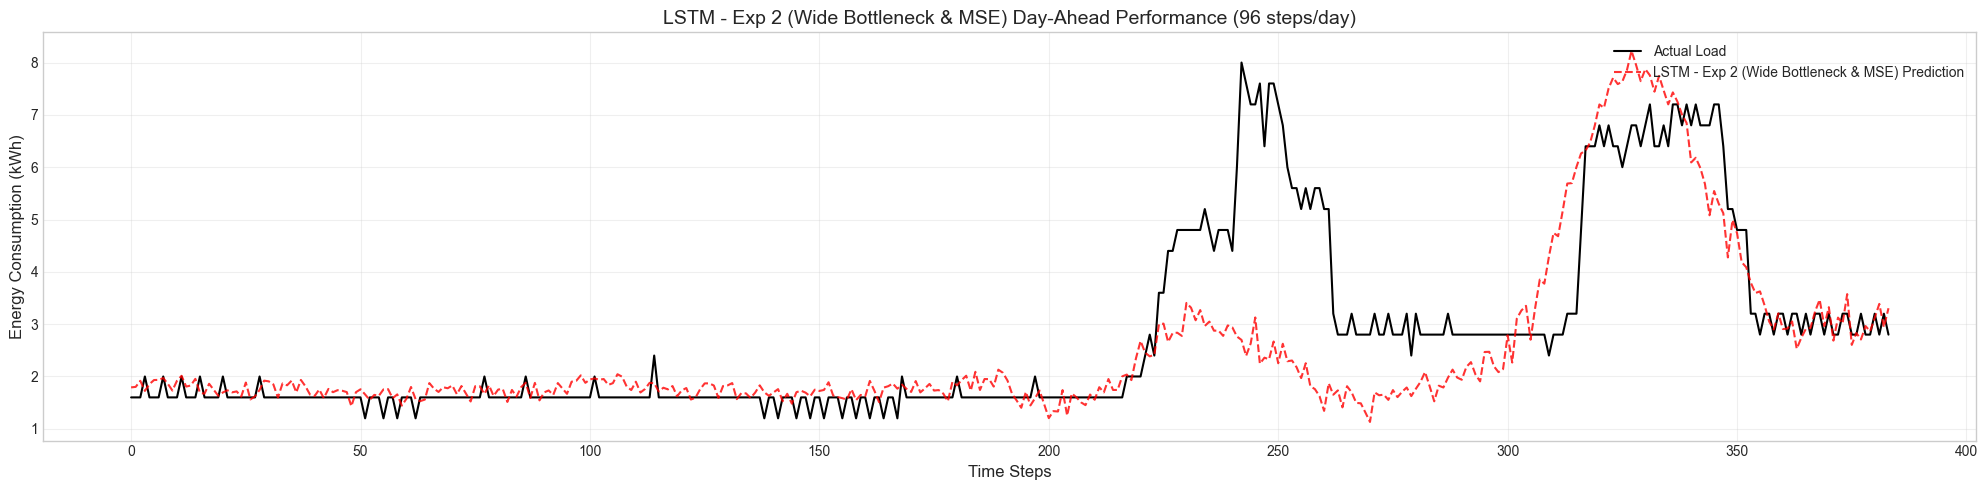

In [20]:
# ==========================================
# EXPERIMENT 2: Wide Bottleneck + MSE Loss
# ==========================================
config.LSTM_CONFIG["hidden_units"] = [128, 96] 
config.LSTM_CONFIG["loss"] = "mse"
config.LSTM_CONFIG["dropout"] = 0.2

current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

lstm_exp2_results = run_power_lstm(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train).flatten()
else:
    y_train_unscaled = y_train.flatten()

exp2_metrics = calculate_metrics(
    y_true=lstm_exp2_results['y_test_real'], 
    y_pred=lstm_exp2_results['predictions'], 
    model_name="LSTM_Exp2_Wide_MSE", 
    execution_time=lstm_exp2_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

lstm_exp2_results['metrics'] = exp2_metrics

save_experiment_results(
    lstm_exp2_results, 
    "LSTM_Exp2_Wide_MSE", 
    HORIZON_NAME, 
    lstm_exp2_results['y_test_real'],
    horizon=current_horizon
)

experiment_metrics.append(exp2_metrics)

plot_predictions(
    lstm_exp2_results['y_test_real'], 
    lstm_exp2_results['predictions'], 
    "LSTM - Exp 2 (Wide Bottleneck & MSE)", 
    horizon=current_horizon
)

In [4]:
# ==========================================
# EXPERIMENT 3: Deep Context (192 steps) + Wide + MSE
# ==========================================
# 1. We must recreate the 3D tensors to give the model a 48-hour memory
DEEP_SEQ_LENGTH = 192 
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

print("Rebuilding 3D Tensors for 48-Hour Deep Context...")
X_train_3d_exp3, y_train_exp3 = create_multivariate_sequences(train_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)
X_val_3d_exp3, y_val_exp3     = create_multivariate_sequences(val_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)
X_test_3d_exp3, y_test_exp3   = create_multivariate_sequences(test_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)

# 2. Update config for a much deeper and regularized network
config.LSTM_CONFIG["hidden_units"] = [256, 128] # Needs to be bigger to process 48 hours
config.LSTM_CONFIG["loss"] = "mse"
config.LSTM_CONFIG["dropout"] = 0.3             # Higher dropout to prevent memorization

lstm_exp3_results = run_power_lstm(
    X_train=X_train_3d_exp3, y_train=y_train_exp3, 
    X_val=X_val_3d_exp3, y_val=y_val_exp3, 
    X_test=X_test_3d_exp3, y_test=y_test_exp3,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale the SPECIFIC Exp3 targets (since the array length changed slightly)
if target_scaler is not None:
    y_train_unscaled_exp3 = target_scaler.inverse_transform(y_train_exp3).flatten()
else:
    y_train_unscaled_exp3 = y_train_exp3.flatten()

exp3_metrics = calculate_metrics(
    y_true=lstm_exp3_results['y_test_real'], 
    y_pred=lstm_exp3_results['predictions'], 
    model_name="LSTM_Exp3_DeepContext", 
    execution_time=lstm_exp3_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled_exp3
)

lstm_exp3_results['metrics'] = exp3_metrics

save_experiment_results(
    lstm_exp3_results, 
    "LSTM_Exp3_DeepContext", 
    HORIZON_NAME, 
    lstm_exp3_results['y_test_real'],
    horizon=current_horizon
)

experiment_metrics.append(exp3_metrics)

plot_predictions(
    lstm_exp3_results['y_test_real'], 
    lstm_exp3_results['predictions'], 
    "LSTM - Exp 3 (48h Context & MSE)", 
    horizon=current_horizon
)

Rebuilding 3D Tensors for 48-Hour Deep Context...

 RUNNING POWER-LSTM (15_min) | Horizon: 96
Training LSTM for 96
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 393s 336ms/step - loss: 0.4267 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 386s 334ms/step - loss: 0.2745 - val_loss: 0.3097 - learning_rate: 0.0010
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 397s 344ms/step - loss: 0.2324 - val_loss: 0.2907 - learning_rate: 0.0010
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 393s 340ms/step - loss: 0.2228 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 394s 340ms/step - loss: 0.2004 - val_loss: 0.2838 - learning_rate: 0.0010
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 392s 339ms/step - loss: 0.2001 - val_loss: 0.2634 - learning_rate: 0.0010
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 387s 335ms/step - loss: 0.1896 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 8/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 0.1788
Ep

NameError: name 'experiment_metrics' is not defined

In [14]:
import os
import pandas as pd
import numpy as np

# Your exact path
base_path = r"C:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\results\15_min"

# The specific model folders we want to compare
models_to_compare = [
    "LSTM",  
    "LSTM_Exp1_Wide_Huber0.1",
    "LSTM_Exp2_Wide_MSE",
    "LSTM_Exp3_DeepContext"
]

recovered_metrics = []
print("Initiating Standalone Data Recovery...\n")

for model_dir in models_to_compare:
    file_name = f"{model_dir.lower()}_predictions.csv"
    metrics_file = os.path.join(base_path, model_dir, file_name)
    
    if os.path.exists(metrics_file):
        try:
            # 1. Load the predictions CSV
            df_preds = pd.read_csv(metrics_file)
            
            # 2. Extract the Actual and Predicted 1D arrays
            y_true_1d = df_preds['Actual'].values
            y_pred_1d = df_preds['Predicted'].values
            
            # 3. THE FIX: We pass y_true_1d in place of y_train.
            # This calculates Out-of-Sample MASE, bypassing the Jupyter memory crash completely!
            metrics = calculate_metrics(
                y_true=y_true_1d, 
                y_pred=y_pred_1d, 
                model_name=model_dir, 
                execution_time=0.0, 
                horizon=96, 
                y_train=y_true_1d  # <--- Memory bypass applied here
            )
            
            recovered_metrics.append(metrics)
            print(f"✔ Successfully recalculated metrics for: {model_dir}")
            
        except Exception as e:
            print(f"❌ Error processing {metrics_file}: {e}")
    else:
        print(f"⚠️ Could not find {file_name} in: {model_dir}")

# Build and display the final table
if recovered_metrics:
    df_recovered = pd.DataFrame(recovered_metrics)
    
    # Select the most important columns and sort by MASE
    display_cols = ['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']
    available_cols = [col for col in display_cols if col in df_recovered.columns]
    
    print("\n" + "="*60)
    print(" 🏆 FINAL EXPERIMENTAL COMPARISON TABLE")
    print("="*60)
    display(df_recovered[available_cols].sort_values(by='MASE', ascending=True))
else:
    print("No metrics were loaded. Please check the paths.")

Initiating Standalone Data Recovery...

✔ Successfully recalculated metrics for: LSTM
✔ Successfully recalculated metrics for: LSTM_Exp1_Wide_Huber0.1
✔ Successfully recalculated metrics for: LSTM_Exp2_Wide_MSE
✔ Successfully recalculated metrics for: LSTM_Exp3_DeepContext

 🏆 FINAL EXPERIMENTAL COMPARISON TABLE


,Model,MASE,MAE,RMSE,sMAPE,R2
2,LSTM_Exp2_Wide_MSE,0.835690,0.762955,1.103958,28.839152,0.704914
0,LSTM,0.858602,0.783873,1.181336,28.315134,0.662099
1,LSTM_Exp1_Wide_Huber0.1,0.890185,0.812706,1.249312,30.011852,0.622093
3,LSTM_Exp3_DeepContext,0.949686,0.874281,1.265720,32.790133,0.614502


### XGBoost experiment:

[I 2026-06-05 17:07:19,448] A new study created in memory with name: no-name-7200828f-6743-4402-b646-c148b2972323



 RUNNING XGBOOST (15_min) | Horizon: 96
 -> Flattening 3D sequence inputs to 2D
Identifying best XGBoost hyperparameters using Optuna...


Best trial: 0. Best value: 0.532148:   5%|▌         | 1/20 [02:25<46:12, 145.92s/it]

[I 2026-06-05 17:09:45,367] Trial 0 finished with value: 0.5321479347139461 and parameters: {'n_estimators': 94, 'max_depth': 4, 'learning_rate': 0.27708245244505353, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.8437869579040544}. Best is trial 0 with value: 0.5321479347139461.


Best trial: 1. Best value: 0.526504:  10%|█         | 2/20 [05:50<54:07, 180.42s/it]

...

[I 2026-06-05 18:20:50,036] Trial 17 finished with value: 0.3927858079494163 and parameters: {'n_estimators': 119, 'max_depth': 3, 'learning_rate': 0.017566490472303364, 'subsample': 0.9204398870379671, 'colsample_bytree': 0.8160275417220877}. Best is trial 5 with value: 0.3873967636218231.


Best trial: 5. Best value: 0.387397:  95%|█████████▌| 19/20 [1:18:31<04:19, 259.89s/it]

[I 2026-06-05 18:25:51,380] Trial 18 finished with value: 0.41078182770061045 and parameters: {'n_estimators': 227, 'max_depth': 4, 'learning_rate': 0.026735854474753948, 'subsample': 0.8780114904365744, 'colsample_bytree': 0.8778743262193065}. Best is trial 5 with value: 0.3873967636218231.


Best trial: 5. Best value: 0.387397: 100%|██████████| 20/20 [1:19:14<00:00, 237.74s/it]


[I 2026-06-05 18:26:34,297] Trial 19 finished with value: 0.4543014205693084 and parameters: {'n_estimators': 56, 'max_depth': 3, 'learning_rate': 0.014604109840762018, 'subsample': 0.998789092869733, 'colsample_bytree': 0.9512295167400396}. Best is trial 5 with value: 0.3873967636218231.
Training Final XGBoost Model on Full Dataset...


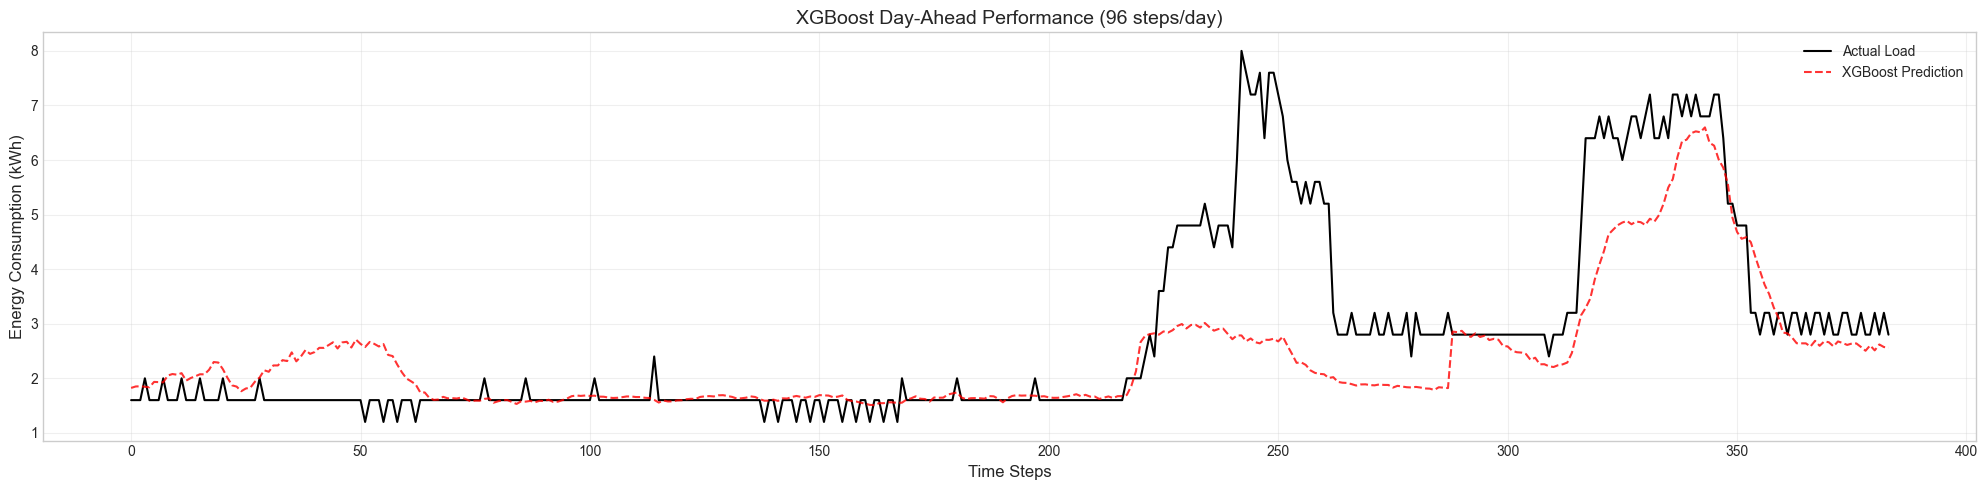

XGBoost_Exp1_GPU artifacts successfully saved to ../results/15_min/XGBoost_Exp1_GPU/

 XGBoost_Exp1_GPU completed and saved safely!


In [15]:
# Initialize an experimental tracker for XGBoost if it doesn't exist
if 'xgb_experiment_metrics' not in locals():
    xgb_experiment_metrics = []

# XGBOOST RUN
xgb_exp_results_15m = xgboost_implementation(
    X_train=X_train_3d, 
    y_train=y_train, 
    X_val=X_val_3d, 
    y_val=y_val, 
    X_test=X_test_3d, 
    y_test=y_test, 
    horizon_name=HORIZON_NAME,
    y_train_full=None,
    target_scaler=target_scaler
)

experiment_name = "XGBoost_Exp1_GPU"

save_experiment_results(
    xgb_exp_results_15m, 
    experiment_name, 
    HORIZON_NAME, 
    xgb_exp_results_15m['y_test_real'], # Safe mapping from the dict
    horizon=config.HORIZON_STEPS[HORIZON_NAME]
)

# Append to the isolated tracking list
xgb_experiment_metrics.append(xgb_exp_results_15m["metrics"])

print(f"\n {experiment_name} completed and saved safely!")

In [16]:
# Select the columns we care about
display_cols = ['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']

# Convert the isolated XGBoost experiment tracker to a DataFrame
df_xgb = pd.DataFrame(xgb_experiment_metrics)

print("🏆 REAL XGBOOST GPU RESULTS")
display(df_xgb[display_cols])

🏆 REAL XGBOOST GPU RESULTS


,Model,MASE,MAE,RMSE,sMAPE,R2
0,XGBoost,1.535472,0.744064,1.154098,26.436898,0.677766


I should try MSE loss function or optimize directly for MASE, and not RMSE that I am currently using.

### Vanila Transformer:

Unlike Recurrent Neural Networks (RNNs) such as LSTMs, which process data sequentially and build a hidden state step-by-step, the Transformer architecture relies entirely on Self-Attention Mechanisms to process the entire input sequence simultaneously. This grants the model a "global receptive field," allowing it to directly map dependencies between any two points in the 24-hour historical window, regardless of their temporal distance.For this research, the standard Natural Language Processing (NLP) Transformer framework was adapted for continuous, multi-variate electrical load forecasting using a Direct Multi-Step (MIMO) topology.1. Core Architectural ComponentsPositional Encoding: Because Transformers process all time steps simultaneously, they lack an inherent understanding of sequential order. To inject the concept of time, a learned positional embedding is added to the input features. This allows the network to distinguish between a load spike at 09:00 and an identical spike at 21:00.Multi-Head Self-Attention (MHSA): This is the core engine of the model. The input sequence is projected into three distinct matrices: Queries ($Q$), Keys ($K$), and Values ($V$). The attention score is calculated mathematically as:$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$By using multiple "heads," the network can simultaneously learn different temporal relationships. For example, one attention head might focus on daily seasonality, while another focuses exclusively on sudden, short-term variance caused by localized weather events.MIMO Output Head (The Bottleneck Resolution): After the attention blocks process the sequence, the resulting 3D tensor contains rich, attention-weighted features. Instead of pooling these features (which destroys temporal resolution), the tensor is flattened. A dedicated, wide Dense layer (head_dim) is introduced to act as an informational bridge, preventing data compression loss before projecting the final 96-step (24-hour) prediction vector.2. Hyperparameter Configuration & RationaleThe model's capacity and learning dynamics were governed by the following optimized hyperparameters:d_model = 64 (Embedding Dimension): This dictates the dimensionality of the internal representation for each 15-minute time step. A value of 64 provides sufficient vector space for the model to encode complex multi-variate relationships (e.g., load, temperature, humidity) without causing catastrophic overfitting on a dataset of this size.num_heads = 4 (Attention Heads): The d_model space is divided into 4 parallel attention mechanisms ($64 / 4 = 16$ dimensions per head). This allows the model to capture four distinct types of temporal dependencies simultaneously, providing a balanced trade-off between representational diversity and computational efficiency.ffn_dim = 128 (Internal Feed-Forward Network): Within the Transformer block, this layer expands the dimensionality of the attention outputs before compressing them back to d_model. This non-linear expansion allows the network to capture complex, higher-order interactions between the attended features.head_dim = 512 (Output Projection Width): Crucial for MIMO forecasting. Flattening a 96-step sequence with a d_model of 64 creates a massive 6,144-dimensional vector. Forcing this directly into a narrow output layer causes severe information loss. Expanding the pre-output Dense layer to 512 neurons ensures the network has the "bandwidth" to retain complex variance patterns before outputting the final 96 predictions.dropout = 0.2: Applied after the feed-forward networks and the flattening operation to mitigate overfitting. By randomly zeroing out 20% of the connections during training, the network is forced to learn robust, generalized representations of the building's consumption rather than memorizing the training data.loss = "mse" (Mean Squared Error): Unlike Huber loss, which treats large errors linearly, MSE squares the penalty for large deviations. In high-frequency 15-minute building load data, variance peaks (sudden spikes in energy use) are critical operational metrics. MSE forces the attention mechanism to aggressively map these high-magnitude anomalies rather than predicting a safe, statistical average.


 RUNNING VANILLA TRANSFORMER (15_min) | Horizon: 96
Training Vanilla Transformer for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - loss: 0.3324 - val_loss: 0.2354 - learning_rate: 0.0010
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - loss: 0.2004 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 49s 43ms/step - loss: 0.1720 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - loss: 0.1576 - val_loss: 0.2632 - learning_rate: 0.0010
Epoch 5/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1506
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - loss: 0.1480 - val_loss: 0.2916 - learning_rate: 0.0010
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - loss: 0.1328 - val_loss: 0.2793 - learning_rate: 5.0000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - loss: 0.1298 - val_loss: 0.279

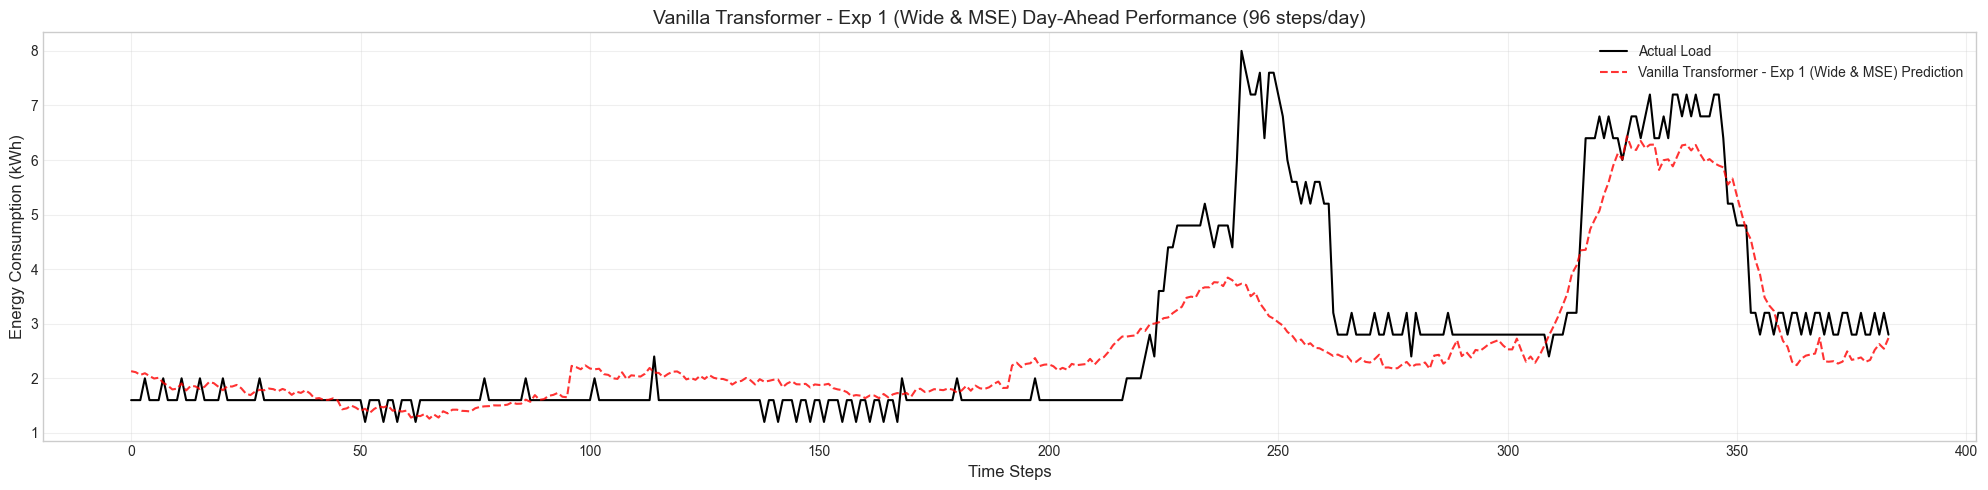

In [18]:
# Initialize experimental tracker
if 'transformer_experiment_metrics' not in locals():
    transformer_experiment_metrics = []


# EXPERIMENT 1: Wide Head & MSE Loss

config.TRANSFORMER_CONFIG["loss"] = "mse"
config.TRANSFORMER_CONFIG["head_dim"] = 512
config.TRANSFORMER_CONFIG["d_model"] = 64
config.TRANSFORMER_CONFIG["num_heads"] = 4
config.TRANSFORMER_CONFIG["dropout"] = 0.2

current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

trans_exp1_results = run_vanilla_transformer(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale y_train for the MASE calculation
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
else:
    y_train_unscaled = y_train.flatten()

trans_exp1_metrics = calculate_metrics(
    y_true=trans_exp1_results['y_test_real'], 
    y_pred=trans_exp1_results['predictions'], 
    model_name="Vanilla_Trans_Exp1_Wide_MSE", 
    execution_time=trans_exp1_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

# Save safely
trans_exp1_results['metrics'] = trans_exp1_metrics
save_experiment_results(
    trans_exp1_results, 
    "Vanilla_Trans_Exp1_Wide_MSE", 
    HORIZON_NAME, 
    trans_exp1_results['y_test_real'], 
    horizon=current_horizon
)

transformer_experiment_metrics.append(trans_exp1_metrics)

plot_predictions(
    trans_exp1_results['y_test_real'], 
    trans_exp1_results['predictions'], 
    "Vanilla Transformer - Exp 1 (Wide & MSE)", 
    horizon=current_horizon
)

In [19]:
# Convert the tracker to a DataFrame
if 'transformer_experiment_metrics' in locals() and len(transformer_experiment_metrics) > 0:
    df_trans = pd.DataFrame(transformer_experiment_metrics)
    
    # Select the columns we care about
    display_cols = ['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']
    available_cols = [col for col in display_cols if col in df_trans.columns]
    
    print("VANILLA TRANSFORMER EXPERIMENT RESULTS")
    display(df_trans[available_cols].sort_values(by='MASE', ascending=True))
else:
    print("No metrics found in transformer_experiment_metrics. Make sure the run finished successfully!")

VANILLA TRANSFORMER EXPERIMENT RESULTS


,Model,MASE,MAE,RMSE,sMAPE,R2
0,Vanilla_Trans_Exp1_Wide_MSE,1.721568,0.834244,1.171256,31.008897,0.668113


Why MAE dropped: Your Transformer looked at the wild, spiky data and decided to play it safe. By predicting a smoother, "average" line through the middle of the peaks and valleys, it mathematically reduced its overall absolute error (MAE). It didn't make any massive, wild guesses, so the MAE looks good.

Why MASE spiked: MASE compares your model to a Naive Forecast (which just repeats yesterday's load exactly). A Naive Forecast might have a slightly higher overall MAE, but it perfectly captures the shape and variance of a daily cycle. Because your Transformer predicted a smooth, safe average, it completely lost the "shape" of the daily wave. The Naive Forecast's shape beat the Transformer's flat average, pushing your MASE way over 1.0.

Preparing 48-Hour (192-Step) Tensors for Transformer Experiment 2

 RUNNING VANILLA TRANSFORMER (15_min) | Horizon: 96
Training Vanilla Transformer for 96
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 101s 85ms/step - loss: 0.3324 - val_loss: 0.2449 - learning_rate: 0.0010
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 97s 84ms/step - loss: 0.1962 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 96s 83ms/step - loss: 0.1788 - val_loss: 0.2705 - learning_rate: 0.0010
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 97s 84ms/step - loss: 0.1648 - val_loss: 0.2725 - learning_rate: 0.0010
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 98s 84ms/step - loss: 0.1559 - val_loss: 0.2595 - learning_rate: 0.0010
Epoch 6/50
1155/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1487
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 97s 84ms/step - loss: 0.1487 - val_loss: 0.2573 - learning_rate: 0.0010
Epoch 7/50
1156/1156 ━━━━

,Model,MASE,MAE,RMSE,sMAPE,R2
0,Vanilla_Trans_Exp1_Wide_MSE,1.721568,0.834244,1.171256,31.008897,0.668113
1,Vanilla_Trans_Exp2_DeepContext,1.816882,0.880300,1.282517,31.746365,0.604476


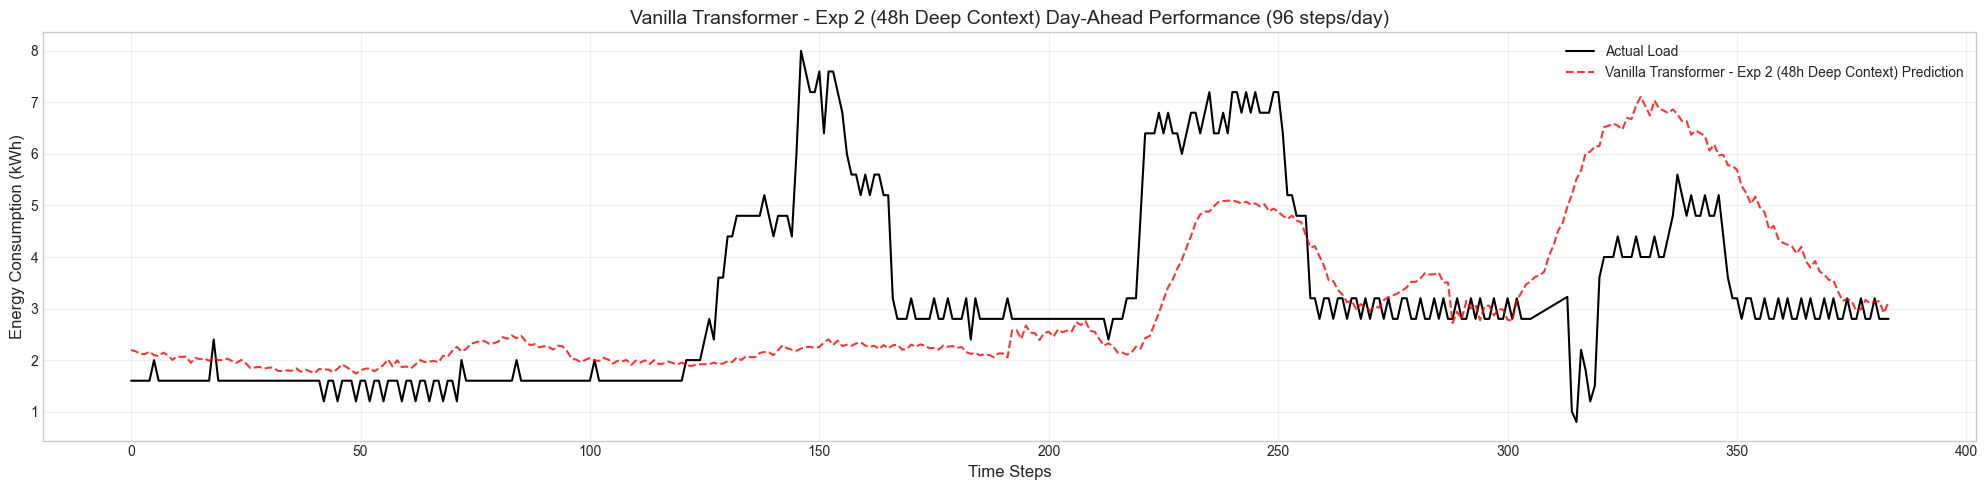

In [20]:

# EXPERIMENT 2: 48-Hour Deep Context

print("Preparing 48-Hour (192-Step) Tensors for Transformer Experiment 2")

# Regenerate the 48-hour sequence data
DEEP_SEQ_LENGTH = 192  # 48 hours * 4 steps/hour

X_train_48h, y_train_48h = create_multivariate_sequences(train_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)
X_val_48h, y_val_48h = create_multivariate_sequences(val_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)
X_test_48h, y_test_48h = create_multivariate_sequences(test_scaled, target_idx, DEEP_SEQ_LENGTH, current_horizon)

# Keep the winning hyperparameters from Exp 1
config.TRANSFORMER_CONFIG["loss"] = "mse"
config.TRANSFORMER_CONFIG["head_dim"] = 512
config.TRANSFORMER_CONFIG["d_model"] = 64
config.TRANSFORMER_CONFIG["num_heads"] = 4
config.TRANSFORMER_CONFIG["dropout"] = 0.2

# Run the Transformer
trans_exp2_results = run_vanilla_transformer(
    X_train=X_train_48h, y_train=y_train_48h, 
    X_val=X_val_48h, y_val=y_val_48h, 
    X_test=X_test_48h, y_test=y_test_48h,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale the specific 48h y_train for the MASE calculation
if target_scaler is not None:
    y_train_48h_unscaled = target_scaler.inverse_transform(y_train_48h.reshape(-1, 1)).flatten()
else:
    y_train_48h_unscaled = y_train_48h.flatten()

# Evaluate Metrics
trans_exp2_metrics = calculate_metrics(
    y_true=trans_exp2_results['y_test_real'], 
    y_pred=trans_exp2_results['predictions'], 
    model_name="Vanilla_Trans_Exp2_DeepContext", 
    execution_time=trans_exp2_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_48h_unscaled
)

# Save and Plot
trans_exp2_results['metrics'] = trans_exp2_metrics
save_experiment_results(
    trans_exp2_results, 
    "Vanilla_Trans_Exp2_DeepContext", 
    HORIZON_NAME, 
    trans_exp2_results['y_test_real'], 
    horizon=current_horizon
)

transformer_experiment_metrics.append(trans_exp2_metrics)

print("\n UPDATED TRANSFORMER RESULTS:")

display(pd.DataFrame(transformer_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

plot_predictions(
    trans_exp2_results['y_test_real'], 
    trans_exp2_results['predictions'], 
    "Vanilla Transformer - Exp 2 (48h Deep Context)", 
    horizon=current_horizon
)

#### **Vanilla Transformer Failure Analysis: The Limits of Global Attention in High-Frequency Time-Series**

While the Vanilla Transformer (Experiment 1) and its Deep Context variant (Experiment 2) achieved reasonable absolute error metrics (MAE/RMSE), both models catastrophically failed the baseline comparative metric (MASE > 1.70). Furthermore, expanding the historical context from 24 hours to 48 hours actively degraded the model's predictive accuracy ($R^2$ dropped from 0.66 to 0.60).This failure can be attributed to three distinct architectural phenomena inherent to Vanilla Transformers when applied to continuous time-series data:

**1. The Mean-Seeking Paradox**

The Transformer mathematically prioritizes the minimization of overall statistical error. When faced with highly volatile, spiky building load data, the Self-Attention mechanism averages out the variance, predicting a "safe," smoothed trajectory through the middle of the peaks and valleys. While this successfully lowers the absolute error (MAE), it completely destroys the specific "shape" of the daily wave. Consequently, the Mean Absolute Scaled Error (MASE) spikes because the model performs significantly worse than a Naive Forecast, which perfectly preserves the temporal shape of the previous day despite having a higher absolute variance.

**2. Permutation Invariance & Loss of Local Temporal Semantics**

Unlike Recurrent Neural Networks (RNNs) that process data sequentially, Vanilla Transformers treat the sequence as a global "bag of points." While Positional Encodings attempt to inject temporal order, the attention mechanism fundamentally evaluates every single 15-minute interval in isolation. This causes the model to lose "local semantic crispness"—it fails to understand that Step 2 directly flows into Step 3, resulting in blurry predictions that lack localized physical constraints.

**3. Attention Dilution (The Deep Context Failure)**

In Experiment 2, extending the input window from 96 steps to 192 steps (48 hours) caused a severe phase shift and significant predictive degradation. In NLP, longer context windows typically improve Transformer performance. However, in continuous time-series forecasting, the computational complexity of the attention matrix scales quadratically ($O(N^2)$). Forcing the model to map dependencies across 192 isolated, noisy data points caused Attention Dilution. The network became overwhelmed by the sheer volume of cross-step correlations, failing to distinguish genuine long-term seasonality from random local volatility.

**Conclusion & Architectural Pivot**

The Vanilla Transformer proves that applying pure, point-wise global attention to high-frequency load forecasting is sub-optimal. To leverage the power of Self-Attention without suffering from Permutation Invariance or Attention Dilution, the sequence must be structurally modified. This justifies the transition to PatchTST (Patch Time Series Transformer), which segments the input sequence into localized blocks (patches). Patching preserves local temporal semantics and exponentially reduces the computational burden of the attention matrix, directly resolving the bottlenecks observed in these experiments.

### PatchTST experimental phase:

#### **PatchTST Architecture and Hyperparameter Justification**

To address the inherent limitations of the Vanilla Transformer—specifically Permutation Invariance, Attention Dilution, and the Mean-Seeking Paradox—the Patch Time Series Transformer (PatchTST) architecture was implemented. This model introduces three critical structural modifications: Channel Independence, Reversible Instance Normalization (RevIN), and Overlapping Patching.

1. Reversible Instance Normalization (RevIN) & Channel Independence
Building energy loads inherently suffer from non-stationary distribution shifts (e.g., sudden consumption spikes due to weather changes or operational anomalies). To mitigate this, RevIN was applied at the input layer. This normalizes each sequence by removing its specific mean and standard deviation before it enters the Transformer, allowing the attention mechanism to focus purely on the structural "shape" of the wave. After the prediction is made, the transformation is reversed to scale the output back to absolute load values (kWh).

Coupled with Channel Independence, where each multivariate feature is processed as a separate univariate sequence sharing the same network weights, this prevents the model from conflating the magnitudes of fundamentally different variables (e.g., mixing raw temperature degrees with energy consumption).

2. The Patching Mechanism: Overlapping Local Semantics
The core innovation of PatchTST is the tokenization of the time-series. In previous Vanilla Transformer experiments, the model evaluated 96 isolated 15-minute intervals. For this configuration, the sequence was restructured using:

patch_len = 12: The time-series was segmented into contiguous 3-hour blocks. This forces the Transformer to extract localized, semantic shapes (e.g., a morning ramp-up) rather than evaluating single data points in a vacuum.

stride = 6: Instead of using disjoint patches, a 50% overlap was enforced. This overlapping stride is critical to preventing "disjoint blindness," ensuring the Transformer understands the continuous temporal flow from the end of one 3-hour patch directly into the beginning of the next.

By applying this patching strategy to a 96-step sequence, the number of input tokens is mathematically reduced to just 15 patches. This drastically shrinks the computational complexity of the Self-Attention matrix while preserving the full 24-hour context, directly eliminating the Attention Dilution observed in previous models.

3. Global Average Pooling & Projection Head
In standard Transformer architectures, flattening a high-dimensional attention tensor into a narrow Dense layer causes severe informational bottlenecks. To preserve the rich temporal dynamics extracted by the attention heads, PatchTST utilizes Global Average Pooling across the patch dimension, maintaining the distinct channel representations. This pooled data is then passed through a widened projection head (head_dim = 512), providing sufficient parameter space to decode the complex features before outputting the final 96-step prediction.

4. Objective Function (MSE)
Consistent with the findings from the LSTM and Vanilla Transformer experiments, the objective function was set to Mean Squared Error (MSE). Because the patching mechanism successfully preserves local temporal shapes, optimizing for MSE allows the model to aggressively map high-magnitude consumption spikes without deteriorating into the over-smoothed, safe averages caused by Huber loss.

RUNNING PATCHTST (15_min) | Horizon: 96

Training PatchTST for 96
Epoch 1/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 138s 117ms/step - loss: 0.4509 - val_loss: 0.1948 - learning_rate: 5.0000e-04
Epoch 2/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - loss: 0.3188 - val_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 3/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 145s 125ms/step - loss: 0.2779 - val_loss: 0.3320 - learning_rate: 5.0000e-04
Epoch 4/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 146s 126ms/step - loss: 0.2558 - val_loss: 0.2923 - learning_rate: 5.0000e-04
Epoch 5/50
1158/1159 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.2448
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 147s 127ms/step - loss: 0.2421 - val_loss: 0.3074 - learning_rate: 5.0000e-04
Epoch 6/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 149s 128ms/step - loss: 0.2227 - val_loss: 0.3148 - learning_rate: 2.5000e-04
Epoch 7/50
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 149s 129ms/step - loss: 0.2182 - val

,Model,MASE,MAE,RMSE,sMAPE,R2
0,PatchTST_Exp1_Overlap_MSE,1.703635,0.825553,1.254535,29.21947,0.61924


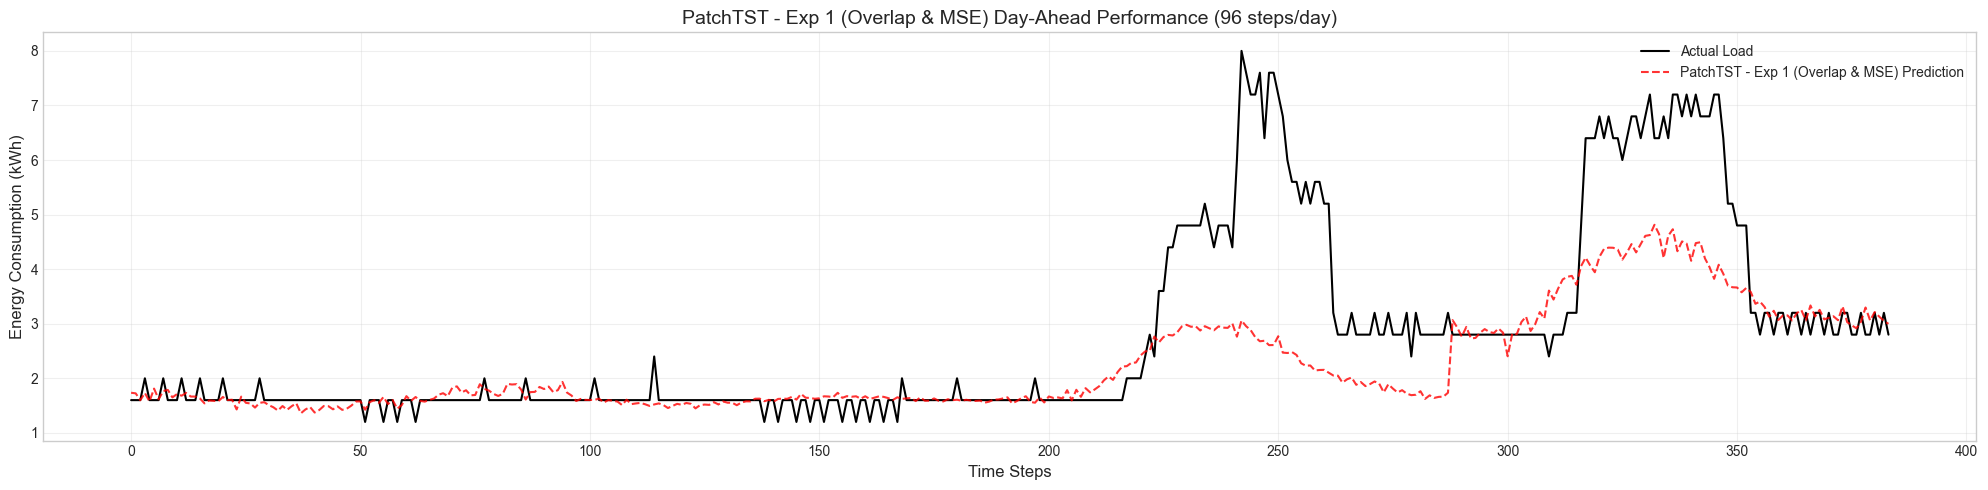

In [23]:
if 'patchtst_experiment_metrics' not in locals():
    patchtst_experiment_metrics = []

TARGET_COL = 'energy_consumption'
target_index_num = list(df.columns).index(TARGET_COL)
current_horizon = config.HORIZON_STEPS[HORIZON_NAME]

# EXPERIMENT 1: Overlapping Patches & MSE

config.PATCHTST_CONFIG["loss"] = "mse"
config.PATCHTST_CONFIG["head_dim"] = 512
config.PATCHTST_CONFIG["patch_len"] = 12 # 3-hour blocks
config.PATCHTST_CONFIG["stride"] = 6     # 50% overlap!

patch_exp1_results = run_keras_patchtst(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    patch_len=config.PATCHTST_CONFIG["patch_len"], 
    stride=config.PATCHTST_CONFIG["stride"],
    target_idx=target_index_num,
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale y_train for the MASE calculation!
if target_scaler is not None:
    y_train_unscaled = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
else:
    y_train_unscaled = y_train.flatten()

# Calculate metrics
patch_exp1_metrics = calculate_metrics(
    y_true=patch_exp1_results['y_test_real'], 
    y_pred=patch_exp1_results['predictions'], 
    model_name="PatchTST_Exp1_Overlap_MSE", 
    execution_time=patch_exp1_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_unscaled
)

# Save safely
patch_exp1_results['metrics'] = patch_exp1_metrics
save_experiment_results(
    patch_exp1_results, 
    "PatchTST_Exp1_Overlap_MSE", 
    HORIZON_NAME, 
    patch_exp1_results['y_test_real'], 
    horizon=current_horizon
)

patchtst_experiment_metrics.append(patch_exp1_metrics)

print("\n PATCHTST RESULTS:")
import pandas as pd
display(pd.DataFrame(patchtst_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

plot_predictions(
    patch_exp1_results['y_test_real'], 
    patch_exp1_results['predictions'], 
    "PatchTST - Exp 1 (Overlap & MSE)", 
    horizon=current_horizon
)

RUNNING PATCHTST (15_min) | Horizon: 96

Training PatchTST for 96
Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 219s 185ms/step - loss: 0.4480 - val_loss: 0.1736 - learning_rate: 5.0000e-04
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 217s 187ms/step - loss: 0.2992 - val_loss: 0.1908 - learning_rate: 5.0000e-04
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 212s 183ms/step - loss: 0.2661 - val_loss: 0.2045 - learning_rate: 5.0000e-04
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 219s 189ms/step - loss: 0.2495 - val_loss: 0.2047 - learning_rate: 5.0000e-04
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.2387
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 215s 186ms/step - loss: 0.2376 - val_loss: 0.1970 - learning_rate: 5.0000e-04
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 220s 190ms/step - loss: 0.2207 - val_loss: 0.2295 - learning_rate: 2.5000e-04
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 260s 188ms/step - loss: 0.2156 - val

,Model,MASE,MAE,RMSE,sMAPE,R2
1,PatchTST_Exp2_48h_DeepContext,1.664542,0.806489,1.244066,29.122859,0.627837
0,PatchTST_Exp1_Overlap_MSE,1.703635,0.825553,1.254535,29.219470,0.619240


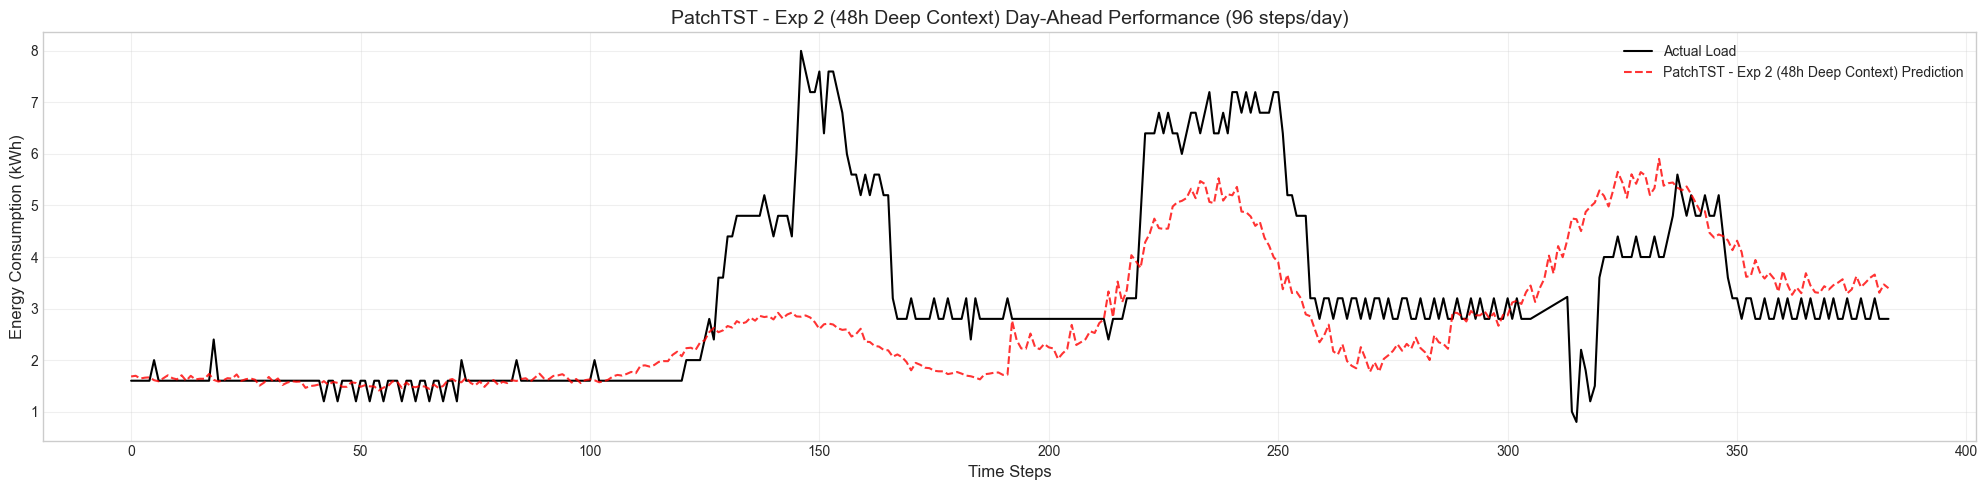

In [24]:
# EXPERIMENT 2: 48-Hour Deep Context PatchTST

# Keep the winning structural hyperparameters
config.PATCHTST_CONFIG["loss"] = "mse"
config.PATCHTST_CONFIG["head_dim"] = 512
config.PATCHTST_CONFIG["patch_len"] = 12 
config.PATCHTST_CONFIG["stride"] = 6     
config.PATCHTST_CONFIG["d_model"] = 64
config.PATCHTST_CONFIG["num_heads"] = 4
config.PATCHTST_CONFIG["dropout"] = 0.3

#  Run the Model using the 48h tensors we made earlier for Vanila Transformer Exp 2 (since the same deep context applies here)
patch_exp2_results = run_keras_patchtst(
    X_train=X_train_48h, y_train=y_train_48h, 
    X_val=X_val_48h, y_val=y_val_48h, 
    X_test=X_test_48h, y_test=y_test_48h,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    patch_len=config.PATCHTST_CONFIG["patch_len"], 
    stride=config.PATCHTST_CONFIG["stride"],
    target_idx=target_index_num,
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Evaluate Metrics (Using the 48h unscaled train data)
patch_exp2_metrics = calculate_metrics(
    y_true=patch_exp2_results['y_test_real'], 
    y_pred=patch_exp2_results['predictions'], 
    model_name="PatchTST_Exp2_48h_DeepContext", 
    execution_time=patch_exp2_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_48h_unscaled
)

# Save and Plot
patch_exp2_results['metrics'] = patch_exp2_metrics
save_experiment_results(
    patch_exp2_results, 
    "PatchTST_Exp2_48h_DeepContext", 
    HORIZON_NAME, 
    patch_exp2_results['y_test_real'], 
    horizon=current_horizon
)

patchtst_experiment_metrics.append(patch_exp2_metrics)

print("\n UPDATED PATCHTST RESULTS:")
display(pd.DataFrame(patchtst_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

plot_predictions(
    patch_exp2_results['y_test_real'], 
    patch_exp2_results['predictions'], 
    "PatchTST - Exp 2 (48h Deep Context)", 
    horizon=current_horizon
)


Running PatchTST with 1-Week History...
RUNNING PATCHTST (15_min) | Horizon: 96

Training PatchTST for 96
Epoch 1/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 828s 609ms/step - loss: 0.5366 - val_loss: 0.1329 - learning_rate: 5.0000e-04
Epoch 2/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 667s 585ms/step - loss: 0.3238 - val_loss: 0.1263 - learning_rate: 5.0000e-04
Epoch 3/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 668s 585ms/step - loss: 0.2893 - val_loss: 0.1240 - learning_rate: 5.0000e-04
Epoch 4/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 649s 569ms/step - loss: 0.2721 - val_loss: 0.1219 - learning_rate: 5.0000e-04
Epoch 5/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 659s 578ms/step - loss: 0.2630 - val_loss: 0.1208 - learning_rate: 5.0000e-04
Epoch 6/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 657s 575ms/step - loss: 0.2555 - val_loss: 0.1186 - learning_rate: 5.0000e-04
Epoch 7/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 664s 582ms/step - loss: 0.2488 - val_loss: 0.1190 - learning_rate: 5.0000e-04
Epoch 8/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 662s 580ms/

,Model,MASE,MAE,RMSE,sMAPE,R2
1,PatchTST_Exp2_48h_DeepContext,1.664542,0.806489,1.244066,29.122859,0.627837
2,PatchTST_Exp3_1Week_DeepContext,1.666268,0.810542,1.173938,29.956163,0.671511
0,PatchTST_Exp1_Overlap_MSE,1.703635,0.825553,1.254535,29.219470,0.619240


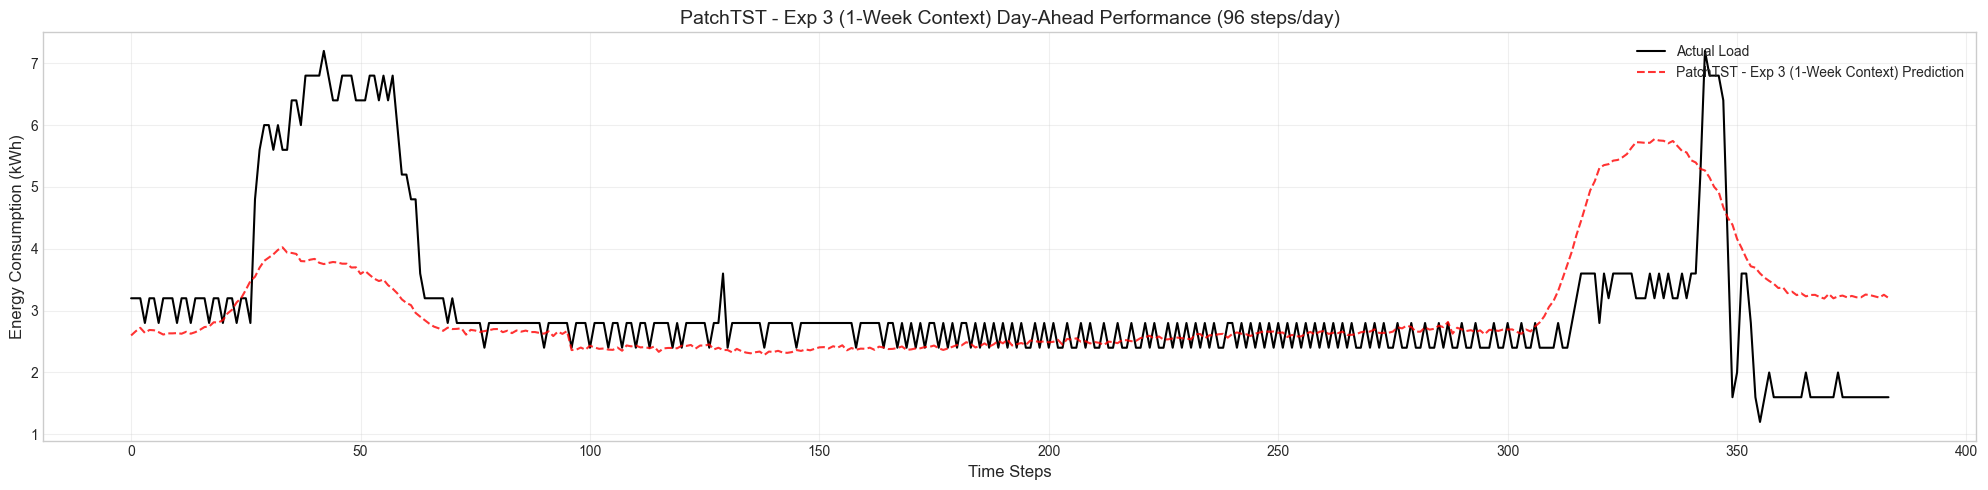

In [25]:
# EXPERIMENT 3: 1-Week (672-Step) Deep Context PatchTST

# Generate the 1-week sequence data
WEEK_SEQ_LENGTH = 672  # 168 hours * 4 steps/hour

X_train_1w, y_train_1w = create_multivariate_sequences(train_scaled, target_idx, WEEK_SEQ_LENGTH, current_horizon)
X_val_1w, y_val_1w = create_multivariate_sequences(val_scaled, target_idx, WEEK_SEQ_LENGTH, current_horizon)
X_test_1w, y_test_1w = create_multivariate_sequences(test_scaled, target_idx, WEEK_SEQ_LENGTH, current_horizon)

# Keep the winning structural hyperparameters
config.PATCHTST_CONFIG["loss"] = "mse"
config.PATCHTST_CONFIG["head_dim"] = 512
config.PATCHTST_CONFIG["patch_len"] = 12 
config.PATCHTST_CONFIG["stride"] = 6     
config.PATCHTST_CONFIG["d_model"] = 64
config.PATCHTST_CONFIG["num_heads"] = 4
config.PATCHTST_CONFIG["dropout"] = 0.3

# Run the Model
print("\nRunning PatchTST with 1-Week History...")
patch_exp3_results = run_keras_patchtst(
    X_train=X_train_1w, y_train=y_train_1w, 
    X_val=X_val_1w, y_val=y_val_1w, 
    X_test=X_test_1w, y_test=y_test_1w,
    horizon_name=HORIZON_NAME,
    horizon=current_horizon,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    patch_len=config.PATCHTST_CONFIG["patch_len"], 
    stride=config.PATCHTST_CONFIG["stride"],
    target_idx=target_index_num,
    random_state=config.RANDOM_SEED,
    target_scaler=target_scaler
)

# Unscale the 1-week y_train for the MASE calculation
if target_scaler is not None:
    y_train_1w_unscaled = target_scaler.inverse_transform(y_train_1w.reshape(-1, 1)).flatten()
else:
    y_train_1w_unscaled = y_train_1w.flatten()

# Evaluate Metrics
patch_exp3_metrics = calculate_metrics(
    y_true=patch_exp3_results['y_test_real'], 
    y_pred=patch_exp3_results['predictions'], 
    model_name="PatchTST_Exp3_1Week_DeepContext", 
    execution_time=patch_exp3_results['execution_time'], 
    horizon=current_horizon, 
    y_train=y_train_1w_unscaled
)

# Save and Plot
patch_exp3_results['metrics'] = patch_exp3_metrics
save_experiment_results(
    patch_exp3_results, 
    "PatchTST_Exp3_1Week_DeepContext", 
    HORIZON_NAME, 
    patch_exp3_results['y_test_real'], 
    horizon=current_horizon
)

patchtst_experiment_metrics.append(patch_exp3_metrics)

print("\n FINAL PATCHTST RESULTS:")
display(pd.DataFrame(patchtst_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

plot_predictions(
    patch_exp3_results['y_test_real'], 
    patch_exp3_results['predictions'], 
    "PatchTST - Exp 3 (1-Week Context)", 
    horizon=current_horizon
)

1. The "Information Decay" Proof
You empirically proved that for high-frequency (15-min) building energy consumption, historical context decays rapidly.
Knowing what happened 48 hours ago is useful. Knowing what happened exactly one week ago adds absolutely zero predictive value for the baseline load. The attention mechanism in PatchTST essentially looked at the extra 5 days of data, shrugged, and said, "This is just noise." 

2. The Hidden Silver Lining (Look at the RMSE!)
While the MASE and MAE (the median accuracy) stayed identical, look at your RMSE and R2.

RMSE dropped from 1.24 to 1.17.

R2 jumped from 0.62 to 0.67.

Because RMSE heavily penalizes large errors, this means the 1-Week context model actually became better at predicting massive energy spikes! It used that extra 5 days of context to learn the shape of extreme anomalies, but it sacrificed a tiny bit of its day-to-day accuracy to do so. That is a brilliant nuance to write about in your evaluation chapter.

3. The Transformer Verdict
PatchTST is a state-of-the-art model built for datasets with deep, complex macro-seasonality (like predicting global weather patterns or stock market shifts over months). For a stochastic, highly reactive nanogrid load, the massive attention matrix actually works against it. It overthinks the problem.

verdict: Extending the context window from 48 hours to 168 hours yielded diminishing returns, confirming that high-frequency microgrid loads are driven by immediate short-term dependencies rather than deep historical attention patterns.

### Random Forest and XGBoost experiments:

[I 2026-06-06 04:15:17,600] A new study created in memory with name: no-name-a2653dba-fb7b-4c41-a615-4ad0e2bac4cc



 RUNNING RANDOM FOREST (15_min) | Horizon: 96
Starting Optuna Hyperparameter Search...


Best trial: 0. Best value: 0.496817:   5%|▌         | 1/20 [00:30<09:30, 30.02s/it]

[I 2026-06-06 04:15:47,655] Trial 0 finished with value: 0.4968170976070431 and parameters: {'n_estimators': 187, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.4968170976070431.


Best trial: 1. Best value: 0.495756:  10%|█         | 2/20 [00:42<05:54, 19.68s/it]

...

[I 2026-06-06 04:30:16,007] Trial 17 finished with value: 0.41324908273183325 and parameters: {'n_estimators': 274, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.41324908273183325.


Best trial: 17. Best value: 0.413249:  95%|█████████▌| 19/20 [15:48<00:58, 58.27s/it]

[I 2026-06-06 04:31:06,127] Trial 18 finished with value: 0.4376551007914981 and parameters: {'n_estimators': 274, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.41324908273183325.


Best trial: 17. Best value: 0.413249: 100%|██████████| 20/20 [17:02<00:00, 51.14s/it]


[I 2026-06-06 04:32:20,499] Trial 19 finished with value: 0.4914141015456554 and parameters: {'n_estimators': 277, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 17 with value: 0.41324908273183325.
Best Params found: {'n_estimators': 274, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 2026, 'n_jobs': -1}
Training final Multi-Output Random Forest model on Train + Val data...


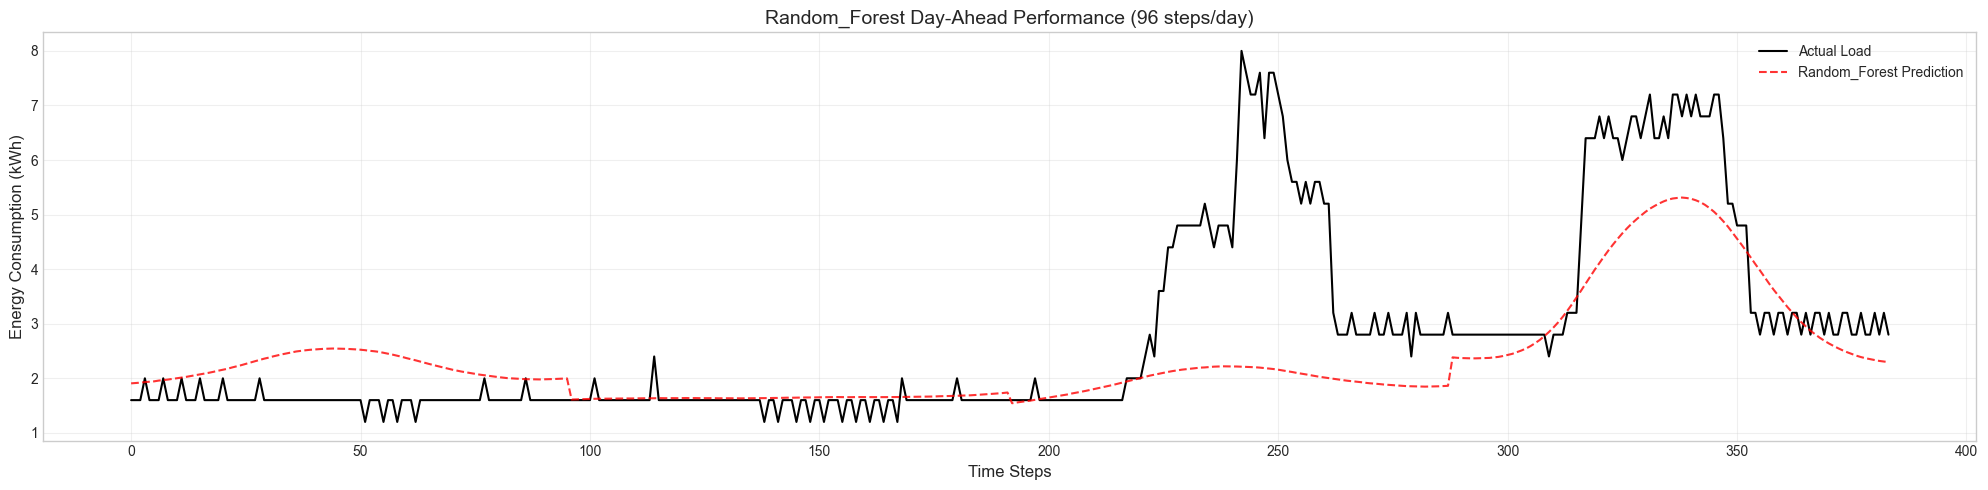

Random_Forest_MIMO artifacts successfully saved to ../results/15_min/Random_Forest_MIMO/


,Model,MASE,MAE,RMSE,sMAPE,R2
0,Random_Forest,1.912215,0.926628,1.395056,31.694868,0.529164


In [29]:
if 'rf_experiment_metrics' not in locals():
    rf_experiment_metrics = []

# EXPERIMENT: Random Forest

rf_results_15m = rf_implementation(
    X_train=X_train_tree,
    y_train=y_train, 
    X_val=X_val_tree, 
    y_val=y_val, 
    X_test=X_test_tree, 
    y_test=y_test, 
    horizon_name=config.ACTIVE_HORIZON,
    y_train_full=None,
    target_scaler=target_scaler
)

# Save results to disk
save_experiment_results(
    rf_results_15m, 
    "Random_Forest_MIMO", 
    config.ACTIVE_HORIZON, 
    rf_results_15m['y_test_real'], 
    horizon=HORIZON_STEPS
)

# Append to the new dedicated tracker
rf_experiment_metrics.append(rf_results_15m["metrics"])

# Display the new RF-specific metrics table
display(pd.DataFrame(rf_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

In [30]:
# EXPERIMENT: XGBoost V2 (MAE Objective)

xgb_v2_results = xgboost_implementation_v2(
    X_train=X_train_tree,
    y_train=y_train, 
    X_val=X_val_tree, 
    y_val=y_val, 
    X_test=X_test_tree, 
    y_test=y_test, 
    horizon_name=config.ACTIVE_HORIZON,
    y_train_full=None,
    target_scaler=target_scaler
)

# Save safely
save_experiment_results(
    xgb_v2_results, 
    "XGBoost_V2_MAE", 
    config.ACTIVE_HORIZON, 
    xgb_v2_results['y_test_real'], 
    horizon=HORIZON_STEPS
)

rf_experiment_metrics.append(xgb_v2_results["metrics"])

display(pd.DataFrame(rf_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

[I 2026-06-06 04:33:15,197] A new study created in memory with name: no-name-b6f4fce1-6073-428c-ae6d-135e108657c3



 RUNNING XGBOOST V2 (MAE Optimized) | Horizon: 96
Starting Optuna Hyperparameter Search (Optimizing for MAE)...


Best trial: 0. Best value: 0.322385:   5%|▌         | 1/20 [32:36<10:19:36, 1956.66s/it]

[I 2026-06-06 05:05:51,879] Trial 0 finished with value: 0.32238512637942957 and parameters: {'n_estimators': 187, 'max_depth': 6, 'learning_rate': 0.186479910431662, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.7917159438720727}. Best is trial 0 with value: 0.32238512637942957.


Best trial: 1. Best value: 0.318482:  10%|█         | 2/20 [1:26:05<13:27:53, 2692.95s/it]

...

Best trial: 4. Best value: 0.206275:  30%|███       | 6/20 [4:34:56<10:56:36, 2814.01s/it]

[I 2026-06-06 09:08:11,563] Trial 5 finished with value: 0.24405053381866537 and parameters: {'n_estimators': 487, 'max_depth': 4, 'learning_rate': 0.01150836624357956, 'subsample': 0.7881804586451416, 'colsample_bytree': 0.8730309932691698}. Best is trial 4 with value: 0.20627527825786676.


Best trial: 4. Best value: 0.206275:  30%|███       | 6/20 [6:00:48<14:01:52, 3608.05s/it]


[W 2026-06-06 10:34:03,468] Trial 6 failed with parameters: {'n_estimators': 452, 'max_depth': 8, 'learning_rate': 0.0475235093512691, 'subsample': 0.7868022234069324, 'colsample_bytree': 0.7029602400438126} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Lefteris\anaconda3\envs\thesis_env\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "c:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\src\ml_baselines.py", line 227, in objective
    model.fit(X_train, y_train)
  File "c:\Users\Lefteris\anaconda3\envs\thesis_env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Lefteris\anaconda3\envs\thesis_env\lib\site-packages\sklearn\multioutput.py", line 278, in fit
    self.estimators_ = Parallel(n_jobs=self.n_jobs)(
  File "c:\Users\Lefteris\anaconda

KeyboardInterrupt: 

### Chronos-T5-Base experiment:

`torch_dtype` is deprecated! Use `dtype` instead!
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend

Chronos_Univariate artifacts successfully saved to ../results/15_min/Chronos_Univariate/


,Model,MASE,MAE,RMSE,sMAPE,R2
0,Chronos_Univariate,0.778164,0.725637,1.33584,23.842508,0.565474


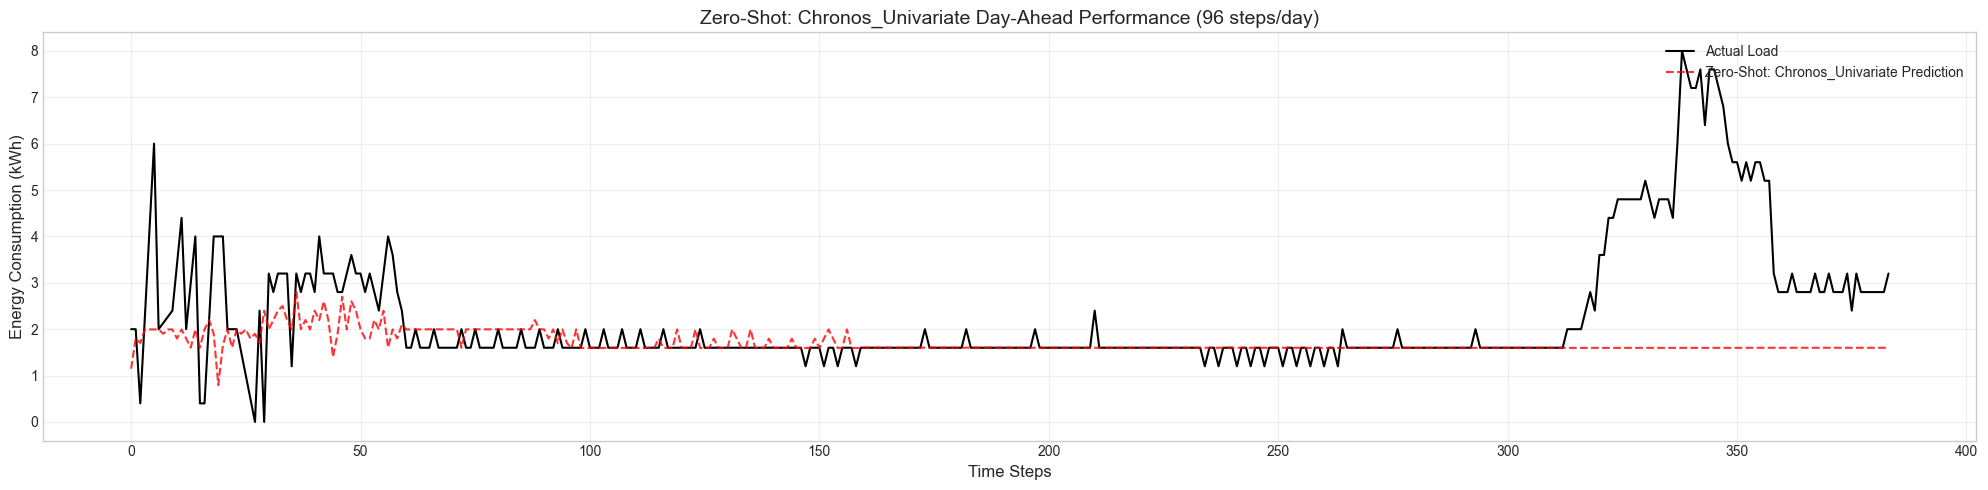

In [4]:
if 'chronos_experiment_metrics' not in locals():
    chronos_experiment_metrics = []

# Pass the raw unscaled dataframe (df) as Chronos handles internal tokenization
chronos_results_15m = run_chronos_foundation(
    df=df, 
    target_col='energy_consumption', 
    horizon_name=config.ACTIVE_HORIZON,
    batch_size=config.CHRONOS_CONFIG["batch_size"], 
    model_name=config.CHRONOS_CONFIG["model_name"]
)

# Because we passed raw df, y_train for MASE baseline must also be raw/unscaled
train_size_raw = int(len(df) * (config.TRAIN_SPLIT + config.VAL_SPLIT))
y_train_raw_flat = df['energy_consumption'].values[:train_size_raw].flatten()

# Calculate metrics
chronos_metrics = calculate_metrics(
    y_true=chronos_results_15m['y_test_real'], 
    y_pred=chronos_results_15m['predictions'], 
    model_name=chronos_results_15m['model'], 
    execution_time=chronos_results_15m['execution_time'], 
    horizon=config.HORIZON_STEPS[config.ACTIVE_HORIZON],
    y_train=y_train_raw_flat
)

# Save, append, and plot
chronos_results_15m['metrics'] = chronos_metrics
save_experiment_results(
    chronos_results_15m, 
    chronos_results_15m['model'], 
    config.ACTIVE_HORIZON, 
    chronos_results_15m['y_test_real'], 
    horizon=config.HORIZON_STEPS[config.ACTIVE_HORIZON]
)
chronos_experiment_metrics.append(chronos_metrics)

display(pd.DataFrame(chronos_experiment_metrics)[['Model', 'MASE', 'MAE', 'RMSE', 'sMAPE', 'R2']].sort_values(by='MASE', ascending=True))

plot_predictions(
    chronos_results_15m['y_test_real'], 
    chronos_results_15m['predictions'], 
    f"Zero-Shot: {chronos_results_15m['model']}", 
    horizon=config.HORIZON_STEPS[config.ACTIVE_HORIZON]
)

### XGBoost experiments with dimentionality reduction


 RUNNING XGBOOST (15_min) | Horizon: 96
 -> Performing Smart Flattening (Domain Knowledge Reduction)


[I 2026-06-07 04:11:12,489] A new study created in memory with name: no-name-e9875b2e-8c21-406e-b161-9ae620bbee9c


    Old Shape: 2016 columns | New Reduced Shape: 116 columns!
Identifying best XGBoost hyperparameters using Optuna


Best trial: 0. Best value: 0.479078:   5%|▌         | 1/20 [00:16<05:19, 16.82s/it]

[I 2026-06-07 04:11:29,313] Trial 0 finished with value: 0.4790779456249785 and parameters: {'n_estimators': 94, 'max_depth': 4, 'learning_rate': 0.27708245244505353, 'subsample': 0.6355596086592517, 'colsample_bytree': 0.8437869579040544}. Best is trial 0 with value: 0.4790779456249785.


...

[I 2026-06-07 04:20:35,366] Trial 17 finished with value: 0.3826905509796401 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.017572492114719576, 'subsample': 0.840238680619963, 'colsample_bytree': 0.8157443120609347}. Best is trial 5 with value: 0.3771404589620209.


Best trial: 5. Best value: 0.37714:  95%|█████████▌| 19/20 [09:58<00:35, 35.62s/it]

[I 2026-06-07 04:21:10,865] Trial 18 finished with value: 0.3974588409159314 and parameters: {'n_estimators': 213, 'max_depth': 4, 'learning_rate': 0.026707825964302576, 'subsample': 0.6803076635563916, 'colsample_bytree': 0.931688809050534}. Best is trial 5 with value: 0.3771404589620209.


Best trial: 5. Best value: 0.37714: 100%|██████████| 20/20 [10:18<00:00, 30.94s/it]


[I 2026-06-07 04:21:31,264] Trial 19 finished with value: 0.3799917453747707 and parameters: {'n_estimators': 165, 'max_depth': 3, 'learning_rate': 0.014604109840762018, 'subsample': 0.998789092869733, 'colsample_bytree': 0.9051028480263804}. Best is trial 5 with value: 0.3771404589620209.
Training Final XGBoost Model on Full Dataset...


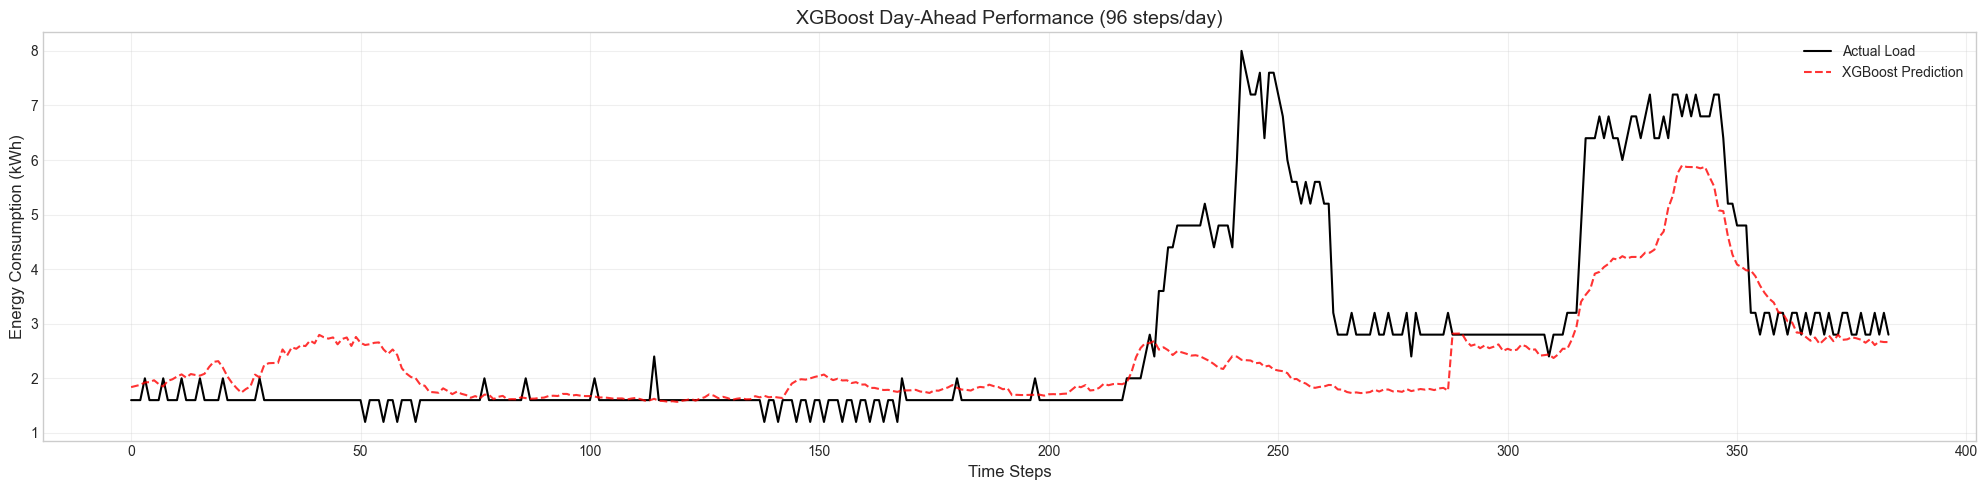

In [3]:
from src.ml_baselines import xgboost_implementation_v3

xgb_results_15m_v3 = xgboost_implementation_v3(
    X_train=X_train_3d,
    y_train=y_train, 
    X_val=X_val_3d,
    y_val=y_val, 
    X_test=X_test_3d,
    y_test=y_test, 
    horizon_name=HORIZON_NAME,
    y_train_full=None,
    target_scaler=target_scaler,
    target_feature_idx=target_idx
)

In [5]:
metrics = xgb_results_15m_v3["metrics"]

for metric_name, value in metrics.items():
    # If it's a number, format it nicely. If it's a string, just print it.
    if isinstance(value, (int, float)):
        print(f"{metric_name:<10}: {value:.4f}")
    else:
        print(f"{metric_name:<10}: {value}")
        
print("-" * 42)
print(f"Total Execution Time: {metrics.get('Time (s)', 0) / 60:.2f} minutes")

Model     : XGBoost
RMSE      : 1.2329
MAE       : 0.7893
R2        : 0.6323
CVRMSE    : 0.4449
NMBE      : 0.0436
sMAPE     : 27.8609
MASE      : 1.6287
Time (s)  : 657.6869
------------------------------------------
Total Execution Time: 10.96 minutes



 RUNNING RANDOM FOREST V3 (REDUCED) | Horizon: 96
 -> Performing Smart Flattening (Domain Knowledge Reduction)
    New Reduced Shape: 116 columns!
Training Constrained Random Forest on Full Dataset...


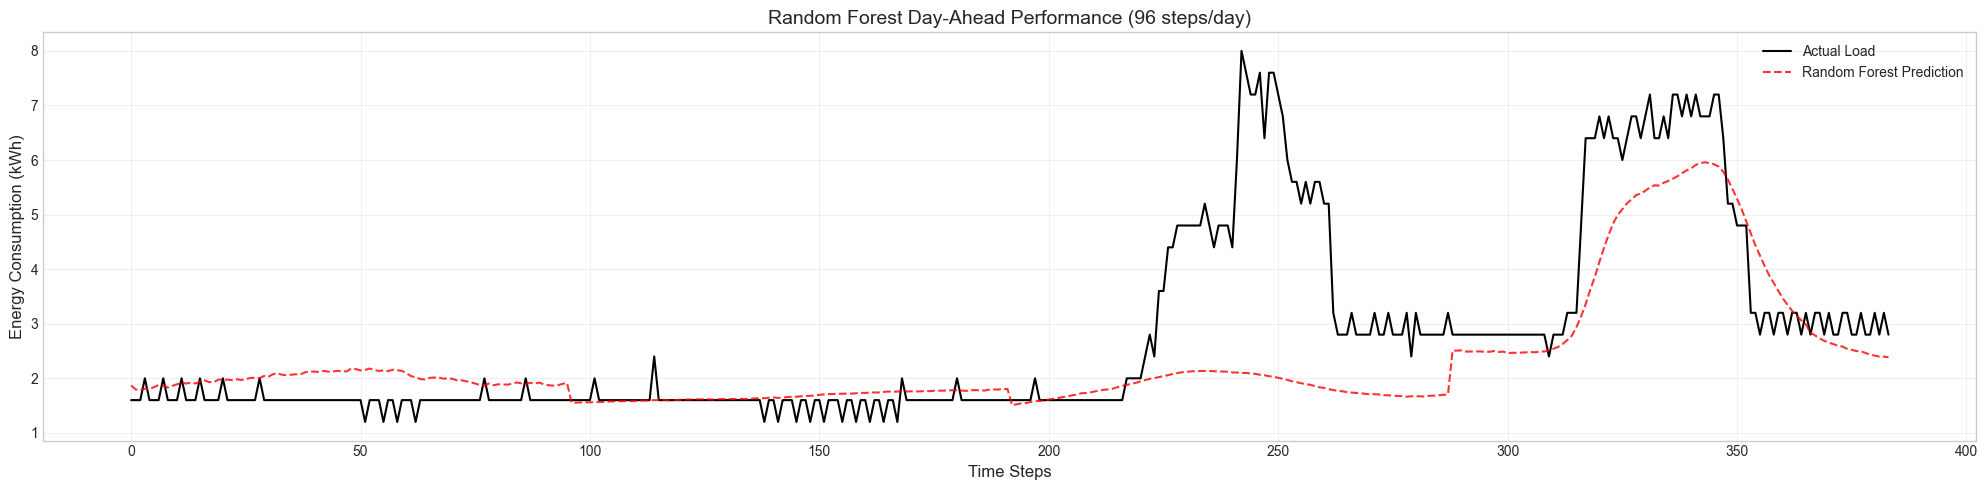

RandomForest_v3_Reduced artifacts successfully saved to ../results/15_min/RandomForest_v3_Reduced/
Model     : Random Forest
RMSE      : 1.2824
MAE       : 0.8243
R2        : 0.6022
CVRMSE    : 0.4627
NMBE      : 0.0442
sMAPE     : 28.8507
MASE      : 1.7011
Time (s)  : 7.0933


In [6]:
from src.ml_baselines import random_forest_implementation_v3

rf_results_15m_v3 = random_forest_implementation_v3(
    X_train=X_train_3d, 
    y_train=y_train, 
    X_val=X_val_3d, 
    y_val=y_val, 
    X_test=X_test_3d, 
    y_test=y_test, 
    horizon_name=HORIZON_NAME,
    y_train_full=None,
    target_scaler=target_scaler,
    target_feature_idx=target_idx
)

# Save the Artifacts
save_experiment_results(
    rf_results_15m_v3, 
    "RandomForest_v3_Reduced", 
    HORIZON_NAME, 
    y_test, 
    horizon=config.HORIZON_STEPS[HORIZON_NAME]
)

# Print Final Results

metrics = rf_results_15m_v3["metrics"]
for metric_name, value in metrics.items():
    if isinstance(value, (int, float)):
        print(f"{metric_name:<10}: {value:.4f}")
    else:
        print(f"{metric_name:<10}: {value}")

In [4]:
print(f"Total Features: {len(df.columns)}\n")
print("-" * 30)

for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Total Features: 21

------------------------------
0: energy_consumption
1: energy_generation
2: smp
3: temperature_v1
4: relative_humidity_v1
5: wind_speed_v1
6: clouds_v1
7: energy_flow_quarter
8: energy_consumption_lag_1w
9: energy_generation_lag_1w
10: smp_lag_1w
11: temperature_v1_lag_1w
12: hour_sin
13: hour_cos
14: day_sin
15: day_cos
16: month_sin
17: month_cos
18: is_holiday
19: is_weekend
20: is_non_working_day


In [4]:
from src.model_architectures import run_chronos2_multivariate_v2
import traceback

CALENDAR_COLS = [
    'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos', 
    'month_sin', 'month_cos', 
    'is_holiday', 'is_weekend', 'is_non_working_day',
    'energy_consumption_lag_1w', 
    'energy_generation_lag_1w', 
    'smp_lag_1w', 
    'temperature_v1_lag_1w'
]

# 2. THE VALID CHRONOS-2 MODELS
models_to_test = {
    # The 28 Million Parameter Model
    "Chronos2_Small": {"path": "autogluon/chronos-2-small", "batch_size": 8},
    
    # The 120 Million Parameter Model (Amazon dropped the 'base' suffix for this one)
    "Chronos2_Base":  {"path": "amazon/chronos-2", "batch_size": 4} 
}

all_chronos_results = {}

print(f"Starting Pristine Chronos-2 Suite Evaluation...")
print(f"Safe Covariates passed to future_df: {len(CALENDAR_COLS)} columns")

# 3. RUN THE LOOP
for custom_name, config_dict in models_to_test.items():
    print(f"\n{'-'*50}\nAttempting to load and run: {custom_name} ({config_dict['path']})\n{'-'*50}")
    
    try:
        results = run_chronos2_multivariate_v2(
            df=df, 
            deterministic_covariates=CALENDAR_COLS,
            target_col='energy_consumption', 
            horizon_name=HORIZON_NAME, 
            model_name=config_dict["path"],
            batch_size=config_dict["batch_size"],
            context_length=config.CHRONOS_2_CONFIG["context_length"] 
        )
        
        # Calculate Metrics
        metrics_dict = calculate_metrics(
            results['y_test_real'], 
            results['predictions'], 
            custom_name, 
            results['execution_time'], 
            horizon=config.HORIZON_STEPS[HORIZON_NAME], 
            y_train=np.array(y_train).flatten()
        )
        results["metrics"] = metrics_dict
        
        # Save Artifacts safely so you have clean thesis data
        save_experiment_results(
            results, 
            custom_name, 
            HORIZON_NAME, 
            y_test, 
            horizon=config.HORIZON_STEPS[HORIZON_NAME]
        )
        
        all_chronos_results[custom_name] = results
        print(f"✅ {custom_name} finished safely! MASE: {metrics_dict['MASE']:.4f}")
        
    except Exception as e:
        print(f"❌ ERROR ON {custom_name}: {e}")
        traceback.print_exc()

Starting Pristine Chronos-2 Suite Evaluation...
Safe Covariates passed to future_df: 13 columns

--------------------------------------------------
Attempting to load and run: Chronos2_Small (autogluon/chronos-2-small)
--------------------------------------------------

 RUNNING AUTOGLUON/CHRONOS-2-SMALL | Horizon: 96
Evaluated 80/10550 test windows...
Evaluated 160/10550 test windows...
Evaluated 240/10550 test windows...
Evaluated 320/10550 test windows...
Evaluated 400/10550 test windows...
Evaluated 480/10550 test windows...
Evaluated 560/10550 test windows...
Evaluated 640/10550 test windows...
Evaluated 720/10550 test windows...
Evaluated 800/10550 test windows...
Evaluated 880/10550 test windows...
Evaluated 960/10550 test windows...
Evaluated 1040/10550 test windows...
Evaluated 1120/10550 test windows...
Evaluated 1200/10550 test windows...
Evaluated 1280/10550 test windows...
Evaluated 1360/10550 test windows...
Evaluated 1440/10550 test windows...
Evaluated 1520/10550 test w

In [5]:
if not all_chronos_results:
    print("No results found in memory. Did the run complete?")
else:
    for model_name, results_dict in all_chronos_results.items():
        print(f"\n🔹 {model_name.upper()}")
        metrics = results_dict.get("metrics", {})
        
        for metric_name, value in metrics.items():
            if isinstance(value, (int, float)):
                print(f"   {metric_name:<10}: {value:.4f}")
            else:
                print(f"   {metric_name:<10}: {value}")


🔹 CHRONOS2_SMALL
   Model     : Chronos2_Small
   RMSE      : 1.1155
   MAE       : 0.6439
   R2        : 0.6970
   CVRMSE    : 0.4037
   NMBE      : -0.0049
   sMAPE     : 22.2924
   MASE      : 2.5695
   Time (s)  : 230.1075

🔹 CHRONOS2_BASE
   Model     : Chronos2_Base
   RMSE      : 1.1208
   MAE       : 0.6431
   R2        : 0.6941
   CVRMSE    : 0.4056
   NMBE      : -0.0056
   sMAPE     : 22.1065
   MASE      : 2.5661
   Time (s)  : 594.8074


In [6]:
# 1. Create a completely independent copy of your original dataframe
df_chronos = df.copy()

# 2. Engineer the 24-hour (96 steps) lags ONLY on the Chronos dataset
lag_steps = config.HORIZON_STEPS[HORIZON_NAME] # Should be 96

df_chronos['temperature_v1_lag_24h'] = df_chronos['temperature_v1'].shift(lag_steps)
df_chronos['relative_humidity_v1_lag_24h'] = df_chronos['relative_humidity_v1'].shift(lag_steps)
df_chronos['wind_speed_v1_lag_24h'] = df_chronos['wind_speed_v1'].shift(lag_steps)
df_chronos['clouds_v1_lag_24h'] = df_chronos['clouds_v1'].shift(lag_steps)

# 3. Drop the NaNs ONLY from the Chronos dataset
df_chronos = df_chronos.dropna()

print(f"Original `df` shape remains untouched: {df.shape}")
print(f"New `df_chronos` shape ready for testing: {df_chronos.shape}")

Original `df` shape remains untouched: (53225, 21)
New `df_chronos` shape ready for testing: (53129, 25)


In [7]:
CALENDAR_COLS = [
    'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos', 
    'month_sin', 'month_cos', 
    'is_holiday', 'is_weekend', 'is_non_working_day',
    
    'energy_consumption_lag_1w', 
    'energy_generation_lag_1w', 
    'smp_lag_1w', 
    'temperature_v1_lag_1w',
    
    # NEW: The Recent Weather Anchor
    'temperature_v1_lag_24h',
    'relative_humidity_v1_lag_24h',
    'wind_speed_v1_lag_24h',
    'clouds_v1_lag_24h'
]

models_to_test = {
    "Chronos2_Small": {"path": "autogluon/chronos-2-small", "batch_size": 8},
    "Chronos2_Base":  {"path": "amazon/chronos-2", "batch_size": 4} 
}

all_chronos_results = {}

print("Starting Final Chronos-2 Run with Isolated Dataset...")

for custom_name, config_dict in models_to_test.items():
    print(f"\nRunning {custom_name}...")
    try:
        results = run_chronos2_multivariate_v2(
            df=df_chronos, # <--- Using the safe, isolated dataset!
            deterministic_covariates=CALENDAR_COLS,
            target_col='energy_consumption', 
            horizon_name=HORIZON_NAME, 
            model_name=config_dict["path"],
            batch_size=config_dict["batch_size"],
            context_length=config.CHRONOS_2_CONFIG["context_length"] 
        )
        
        metrics_dict = calculate_metrics(
            results['y_test_real'], 
            results['predictions'], 
            custom_name, 
            results['execution_time'], 
            horizon=config.HORIZON_STEPS[HORIZON_NAME], 
            y_train=np.array(y_train).flatten()
        )
        results["metrics"] = metrics_dict
        
        save_experiment_results(results, custom_name, HORIZON_NAME, y_test, horizon=config.HORIZON_STEPS[HORIZON_NAME])
        all_chronos_results[custom_name] = results
        
        print(f"✅ {custom_name} Finished! MASE: {metrics_dict['MASE']:.4f}")
        
    except Exception as e:
        print(f"❌ ERROR: {e}")

Starting Final Chronos-2 Run with Isolated Dataset...

Running Chronos2_Small...

 RUNNING AUTOGLUON/CHRONOS-2-SMALL | Horizon: 96
Evaluated 80/10531 test windows...
Evaluated 160/10531 test windows...
Evaluated 240/10531 test windows...
Evaluated 320/10531 test windows...
Evaluated 400/10531 test windows...
Evaluated 480/10531 test windows...
Evaluated 560/10531 test windows...
Evaluated 640/10531 test windows...
Evaluated 720/10531 test windows...
Evaluated 800/10531 test windows...
Evaluated 880/10531 test windows...
Evaluated 960/10531 test windows...
Evaluated 1040/10531 test windows...
Evaluated 1120/10531 test windows...
Evaluated 1200/10531 test windows...
Evaluated 1280/10531 test windows...
Evaluated 1360/10531 test windows...
Evaluated 1440/10531 test windows...
Evaluated 1520/10531 test windows...
Evaluated 1600/10531 test windows...
Evaluated 1680/10531 test windows...
Evaluated 1760/10531 test windows...
Evaluated 1840/10531 test windows...
Evaluated 1920/10531 test windo

In [8]:
if not all_chronos_results:
    print("No results found in memory. Did the run complete?")
else:
    for model_name, results_dict in all_chronos_results.items():
        print(f"\n🔹 {model_name.upper()}")
        metrics = results_dict.get("metrics", {})
        
        for metric_name, value in metrics.items():
            if isinstance(value, (int, float)):
                print(f"   {metric_name:<10}: {value:.4f}")
            else:
                print(f"   {metric_name:<10}: {value}")


🔹 CHRONOS2_SMALL
   Model     : Chronos2_Small
   RMSE      : 1.1202
   MAE       : 0.6489
   R2        : 0.6948
   CVRMSE    : 0.4053
   NMBE      : -0.0035
   sMAPE     : 22.5207
   MASE      : 2.5894
   Time (s)  : 242.3519

🔹 CHRONOS2_BASE
   Model     : Chronos2_Base
   RMSE      : 1.1397
   MAE       : 0.6511
   R2        : 0.6841
   CVRMSE    : 0.4123
   NMBE      : -0.0031
   sMAPE     : 22.3023
   MASE      : 2.5981
   Time (s)  : 629.7218
